# Week 09 — Capstone BBO Experiments

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import sys
sys.path.append('../src')

# ML imports
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF
from sklearn.model_selection import LeaveOneOut, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from scipy.spatial.distance import cdist

warnings.filterwarnings('ignore', message='R.*score is not well-defined')

# Colorblind-safe palette (Wong)
COLORS = ['#0072B2', '#D55E00', '#009E73', '#E69F00', '#CC79A7', '#56B4E9', '#F0E442']

In [2]:
def load_function(n):
    X = np.load(f'../data/function_{n}/initial_inputs.npy')
    Y = np.load(f'../data/function_{n}/initial_outputs.npy')
    print(f"Function {n}: {X.shape[0]} points, {X.shape[1]}D, best y = {Y.max():.4f}")
    return X, Y

## Function 1

In [3]:
# Cell A — F1 setup + data overview
N = 1
X, Y = load_function(N)
baseline = float(Y.std())
print(f"F{N}: {X.shape[0]} pts, {X.shape[1]}D | baseline RMSE = {baseline:.4e} | Y range [{Y.min():.3e}, {Y.max():.3e}]")
print(f"Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))

labels = ['init']*10 + [f'W{w}' for w in range(1, 9)]
order = np.argsort(-Y)
print("\nAll points sorted by Y (W8 marked ★):")
for rank in range(len(order)):
    idx = int(order[rank])
    sign = '+' if Y[idx] > 0 else '-' if Y[idx] < -1e-100 else '0'
    star = ' ★' if idx == len(Y)-1 else ''
    print(f"  {rank+1:>2}. ({X[idx,0]:.4f}, {X[idx,1]:.4f}) Y={Y[idx]:+.3e}  [{labels[idx]:>4}]  {sign}{star}")
print(f"\nPositives: {int((Y>0).sum())}, Negatives: {int((Y<0).sum())}")

# Outlier sensitivity check (standard since W8)
i_worst = int(Y.argmin())
print("\nCorrelation sensitivity to worst point:")
for d in range(X.shape[1]):
    r_all = np.corrcoef(X[:,d], Y)[0,1]
    r_no = np.corrcoef(np.delete(X[:,d], i_worst), np.delete(Y, i_worst))[0,1]
    flag = ' ⚠ FLIPPED' if abs(r_no-r_all) > 0.2 else ''
    print(f"  x{d+1}: r_all={r_all:+.3f}, r_no_worst={r_no:+.3f}{flag}")


Function 1: 18 points, 2D, best y = 0.0000
F1: 18 pts, 2D | baseline RMSE = 1.6850e-03 | Y range [-6.627e-03, 3.651e-07]
Per-dim corr: r(x1,Y)=+0.072, r(x2,Y)=-0.012

All points sorted by Y (W8 marked ★):
   1. (0.7002, 0.6954) Y=+3.651e-07  [  W3]  +
   2. (0.7243, 0.7020) Y=+1.133e-10  [  W8]  + ★
   3. (0.7310, 0.7330) Y=+7.711e-16  [init]  +
   4. (0.6654, 0.4374) Y=+1.894e-28  [  W4]  +
   5. (0.7800, 0.7800) Y=+2.500e-32  [  W2]  +
   6. (0.6834, 0.8611) Y=+2.535e-40  [init]  +
   7. (0.2287, 0.5658) Y=+6.244e-42  [  W5]  +
   8. (0.5743, 0.8799) Y=+1.033e-46  [init]  +
   9. (0.8839, 0.5823) Y=+6.230e-48  [init]  +
  10. (0.3194, 0.7630) Y=+1.323e-79  [init]  +
  11. (0.0825, 0.4035) Y=+3.607e-81  [init]  +
  12. (0.8404, 0.2647) Y=+3.342e-124  [init]  +
  13. (0.3127, 0.0787) Y=-2.089e-91  [init]  -
  14. (0.6172, 0.2223) Y=-1.809e-57  [  W6]  -
  15. (0.4104, 0.1476) Y=-2.159e-54  [init]  -
  16. (0.2736, 0.3090) Y=-2.075e-25  [  W7]  -
  17. (0.6501, 0.6815) Y=-3.606e-03  [in

/tmp/claude-502/ipykernel_40144/1153773052.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5'])
/tmp/claude-502/ipykernel_40144/1153773052.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5'])


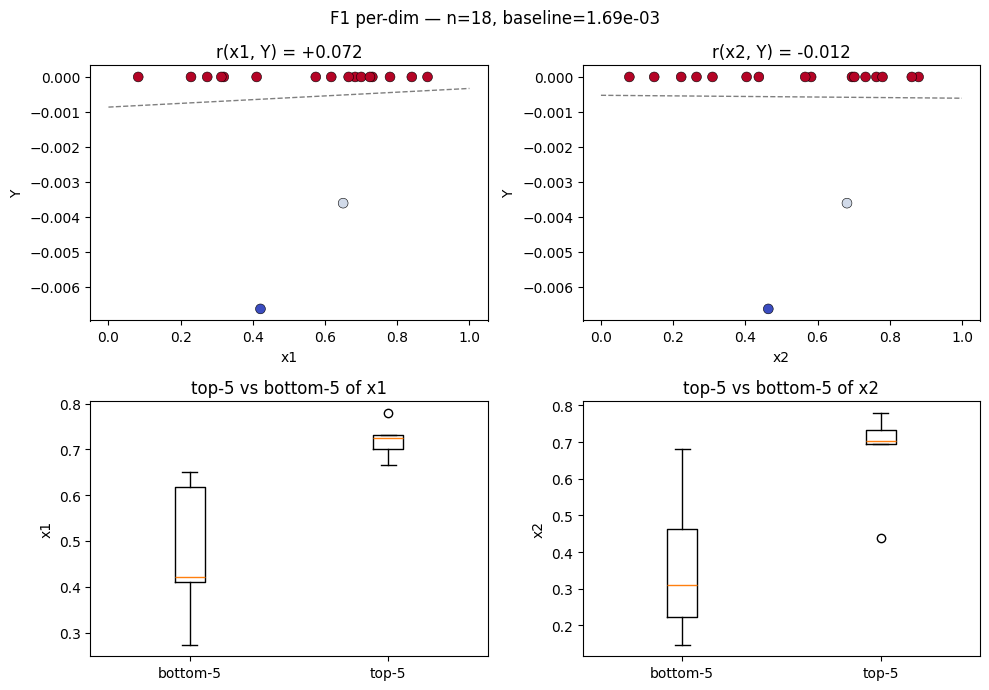

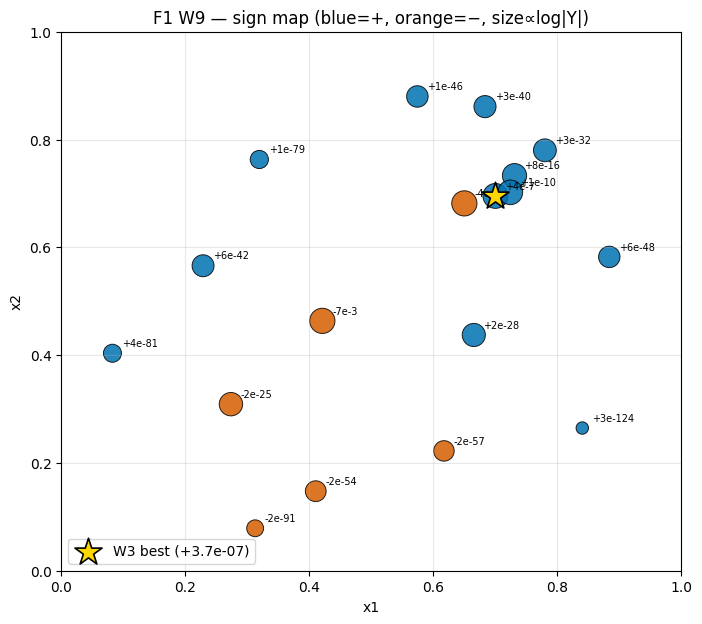

In [4]:
# Cell B — F1 per-dim + 2D scatter + sign-aware map
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import os
os.makedirs('../plots/week_09', exist_ok=True)

# B1: per-dim scatter + boxplots
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for i in range(2):
    axes[0, i].scatter(X[:, i], Y, c=Y, cmap='coolwarm', s=50, edgecolors='k', linewidths=0.4)
    z = np.polyfit(X[:, i], Y, 1); xs = np.linspace(0, 1, 50)
    axes[0, i].plot(xs, np.polyval(z, xs), 'k--', lw=1, alpha=0.5)
    r = np.corrcoef(X[:, i], Y)[0, 1]
    axes[0, i].set(xlabel=f'x{i+1}', ylabel='Y', title=f'r(x{i+1}, Y) = {r:+.3f}')
top5 = np.argsort(Y)[-5:]; bot5 = np.argsort(Y)[:5]
for i in range(2):
    axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5'])
    axes[1, i].set(ylabel=f'x{i+1}', title=f'top-5 vs bottom-5 of x{i+1}')
plt.suptitle(f'F1 per-dim — n={len(Y)}, baseline={baseline:.2e}')
plt.tight_layout(); plt.savefig('../plots/week_09/function_1_per_dim.png', dpi=110, bbox_inches='tight'); plt.show()

# B2: sign-aware 2D map (size by log|Y|, colour by sign)
fig, ax = plt.subplots(1, 1, figsize=(8, 7))
mag = np.log10(np.abs(Y) + 1e-200)
sizes = 80 + 250 * (mag - mag.min()) / (mag.max() - mag.min() + 1e-12)
colors_pn = np.where(Y > 0, COLORS[0], COLORS[1])
ax.scatter(X[:, 0], X[:, 1], c=colors_pn, s=sizes, edgecolors='k', linewidths=0.7, alpha=0.85)
for i, (xi, yi) in enumerate(X):
    ax.annotate(f'{Y[i]:+.0e}'.replace('e+0','e+').replace('e-0','e-'), (xi, yi), xytext=(7, 5), textcoords='offset points', fontsize=7)
i_best = int(Y.argmax())
ax.scatter([X[i_best,0]], [X[i_best,1]], marker='*', s=420, facecolor='gold', edgecolor='black', linewidths=1.2, zorder=5, label=f'W3 best (+{Y.max():.1e})')
ax.set(xlim=(0,1), ylim=(0,1), xlabel='x1', ylabel='x2', title='F1 W9 — sign map (blue=+, orange=−, size∝log|Y|)')
ax.legend(loc='lower left'); ax.grid(alpha=0.3)
plt.savefig('../plots/week_09/function_1_2d_scatter.png', dpi=110, bbox_inches='tight'); plt.show()


In [5]:
# Cell C — F1 feature importance robustness
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
i_best_local = int(Y.argmax()); i_worst = int(Y.argmin())
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_no_best = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_best_local, 0), np.delete(Y, i_best_local)).feature_importances_
lin_coef = np.abs(LinearRegression().fit(X, Y).coef_); lin_norm = lin_coef/(lin_coef.sum()+1e-12)
corr_abs = np.array([abs(np.corrcoef(X[:, i], Y)[0, 1]) for i in range(X.shape[1])])
print(f"{'Dim':>4}  {'RF (all)':>9}  {'RF (no best)':>13}  {'Linear':>8}  {'|corr|':>7}  flag")
for d in range(X.shape[1]):
    drop = (rf_all[d]-rf_no_best[d])/(rf_all[d]+1e-12)*100 if rf_all[d]>0 else 0
    print(f"  x{d+1}  {rf_all[d]:>9.3f}  {rf_no_best[d]:>13.3f}  {lin_norm[d]:>8.3f}  {corr_abs[d]:>7.3f}  {'⚠' if drop>50 else ''}")


 Dim   RF (all)   RF (no best)    Linear   |corr|  flag
  x1      0.548          0.531     0.686    0.072  
  x2      0.452          0.469     0.314    0.012  


In [6]:
# Cell D — F1 model grid search
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_score
import nn_models as nm
cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1); gs.fit(X, Y)
    return name, -gs.best_score_, gs.best_estimator_
results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN',   KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF',    RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR',   SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB',    GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
for nm_, kfn in [('GP-Matern05', lambda: ConstantKernel()*Matern(0.3,nu=0.5)),
                 ('GP-Matern15', lambda: ConstantKernel()*Matern(0.3,nu=1.5)),
                 ('GP-Matern25', lambda: ConstantKernel()*Matern(0.3,nu=2.5)),
                 ('GP-RBF',      lambda: ConstantKernel()*RBF(0.3))]:
    gp = GaussianProcessRegressor(kernel=kfn(), normalize_y=True, alpha=1e-10, n_restarts_optimizer=3, random_state=0)
    score = -cross_val_score(gp, X, Y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
    results.append((nm_, score, gp.fit(X, Y)))
nn_models_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_09')
results.append(('NN', nn_meta['cv_rmse'], nm.NNRegressor(nn_models_loaded, nn_meta)))
print(f"{'Model':>13}  {'RMSE':>11}  beats?")
beats_models = {}
for name, rmse, est in results:
    if rmse < baseline: beats_models[name] = (est, rmse)
    print(f"  {name:>11}  {rmse:>11.4e}  {'✓' if rmse<baseline else '✗'}")
print(f"\n{len(beats_models)} models beat baseline (={baseline:.4e})")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v

        Model         RMSE  beats?
        Ridge   1.0710e-03  ✓
          KNN   9.1592e-04  ✓
           RF   1.2521e-03  ✓
          SVR   3.2297e-03  ✗
           GB   1.1826e-03  ✓
  GP-Matern05   1.0795e-03  ✓
  GP-Matern15   1.0751e-03  ✓
  GP-Matern25   1.1106e-03  ✓
       GP-RBF   1.0702e-03  ✓
           NN   2.7748e-03  ✗

8 models beat baseline (=1.6850e-03)


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v

In [7]:
# Cell E — F1 maxima-seeker filter + ensemble
rng = np.random.default_rng(0)
cand = rng.uniform(size=(200_000, 2))
print(f"{'Model':>13}  {'x1':>7}  {'x2':>7}  {'pred Y':>11}  type")
suggestions = {}
for name, (est, rmse) in beats_models.items():
    yhat = est.predict(cand); i = int(yhat.argmax()); pt = cand[i].copy()
    on_b = bool((pt < 0.02).any() or (pt > 0.98).any())
    suggestions[name] = {'x': pt, 'y_hat': float(yhat[i]), 'boundary': on_b, 'rmse': rmse}
    typ = 'BOUNDARY' if on_b else ('maxima-seeker' if yhat[i] > 0 else 'valley-tracker')
    print(f"  {name:>11}  {pt[0]:>7.4f}  {pt[1]:>7.4f}  {yhat[i]:>11.3e}  {typ}")

# Keep interior, non-Ridge, positive-predicting models
maxima = {n: s for n, s in suggestions.items() if n != 'Ridge' and not s['boundary'] and s['y_hat'] > 0}
print(f"\nInterior maxima-seekers: {list(maxima.keys())}")
pts = np.array([s['x'] for s in maxima.values()])
maxima_ensemble = pts.mean(axis=0)
print(f"Maxima-seeker ensemble: ({maxima_ensemble[0]:.4f}, {maxima_ensemble[1]:.4f})")
P_best = X[Y.argmax()]
print(f"W3 best: ({P_best[0]:.4f}, {P_best[1]:.4f}), step from best: ({maxima_ensemble[0]-P_best[0]:+.4f}, {maxima_ensemble[1]-P_best[1]:+.4f})")


        Model       x1       x2       pred Y  type
        Ridge   0.9993   0.0046   -5.658e-04  BOUNDARY
          KNN   0.6997   0.6965    3.478e-07  maxima-seeker
           RF   0.0410   0.0165    2.518e-13  BOUNDARY
           GB   0.9972   0.9808   -2.238e-04  BOUNDARY
  GP-Matern05   0.7240   0.7023    7.268e-08  maxima-seeker


  GP-Matern15   0.7086   0.7004    1.417e-04  maxima-seeker
  GP-Matern25   0.6370   0.2698   -5.685e-04  valley-tracker
       GP-RBF   0.6370   0.2698   -5.685e-04  valley-tracker

Interior maxima-seekers: ['KNN', 'GP-Matern05', 'GP-Matern15']
Maxima-seeker ensemble: (0.7107, 0.6997)
W3 best: (0.7002, 0.6954), step from best: (+0.0105, +0.0044)


In [8]:
# Cell F — F1 SVC sign classifier + log-SVR (always run for F1)
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, LeaveOneOut
sign_y = (Y > 0).astype(int)
clf = GridSearchCV(SVC(kernel='rbf', gamma='scale'), {'C':[1,10,100]}, scoring='accuracy', cv=LeaveOneOut(), n_jobs=1)
clf.fit(X, sign_y)
clf_acc = clf.best_score_
print(f"SVC sign classifier: best C={clf.best_params_['C']}, LOO accuracy = {clf_acc:.2%}")
print(f"  85% trust gate: {'✓ FIRES' if clf_acc >= 0.85 else f'✗ below by {(0.85-clf_acc)*100:.1f}pp'}")
print(f"  sign distribution: {int(sign_y.sum())} pos / {int((1-sign_y).sum())} neg")

log_abs_Y = np.log10(np.abs(Y) + 1e-200)
log_svr = GridSearchCV(SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}, scoring='neg_root_mean_squared_error', cv=LeaveOneOut(), n_jobs=1)
log_svr.fit(X, log_abs_Y)
print(f"log-SVR on log10|Y|: RMSE={-log_svr.best_score_:.3f} vs baseline {log_abs_Y.std():.3f} ({'✓' if -log_svr.best_score_ < log_abs_Y.std() else '✗'})")
print("Classifier still below 85% gate → combined approach not trusted; using maxima-seeker ensemble (Cell E).")


SVC sign classifier: best C=1, LOO accuracy = 83.33%
  85% trust gate: ✗ below by 1.7pp
  sign distribution: 12 pos / 6 neg
log-SVR on log10|Y|: RMSE=12.481 vs baseline 32.489 (✓)
Classifier still below 85% gate → combined approach not trusted; using maxima-seeker ensemble (Cell E).


### F1 — Decision

**Query: `next_query_1 = maxima_ensemble` → (0.711, 0.700)**

Method: Branch 5 (strong-but-disagreeing) maxima-seeker ensemble. Of the 8 models beating baseline, I keep only the interior, positive-predicting ones (KNN, GP-Matern05, GP-Matern15) and average them. Valley-trackers (Ridge, GB, GP-Matern25, GP-RBF) point at the negative region and are filtered; RF's corner suggestion is boundary-rejected.

Why: W8's gradient-climb (0.724, 0.702) overshot — Y dropped from W3's 3.65e-7 to 1.1e-10, telling us the positive ridge is narrow and centred near W3 best (0.700, 0.695). The three maxima-seekers now cluster on that ridge between W3 and W8. Their mean (0.711, 0.700) refines the ridge interior. SVC classifier is at 83.33% LOO (up from 82.35% W8), still 1.7pp below the 85% gate, so the combined classifier+log-SVR path stays closed one more week.

Branch (Step 5):
- [ ] 1-4 (not used)
- [x] 5. Strong but disagreeing → maxima-seeker ensemble (positive-predicting models only), valley-trackers filtered

Per-dimension justification:
- x1 = 0.711 (mean of KNN 0.700, GP-Matern05 0.724, GP-Matern15 0.709)
- x2 = 0.700 (mean of KNN 0.697, GP-Matern05 0.702, GP-Matern15 0.700)

W10 contingency:
- If Y > 3.65e-7 (new best): ridge interior is richer than W3. Refine tighter around the new point.
- If Y ∈ [0, 3.65e-7]: ridge confirmed narrow at W3. Probe the unexplored perpendicular (lower x2 ≈ 0.66 at x1 ≈ 0.70) to map ridge width.
- If Y < 0: the ridge is sharper than the 0.011 step; pull straight back to W3 best and probe perpendicular.
- If classifier crosses 85%: open the combined classifier+log-SVR path.


In [9]:
# Cell I — next_query_1 assignment
next_query_1 = maxima_ensemble.copy()
print(f"F1 query: {next_query_1[0]:.6f}, {next_query_1[1]:.6f}")
print(f"  Method: maxima-seeker ensemble (interior positive-predicting models)")


F1 query: 0.710746, 0.699736
  Method: maxima-seeker ensemble (interior positive-predicting models)


## Function 2

In [10]:
# Cell A — F2 setup + data overview
N = 2
X, Y = load_function(N)
baseline = float(Y.std())
print(f"F{N}: {X.shape[0]} pts, {X.shape[1]}D | baseline RMSE = {baseline:.4f} | Y range [{Y.min():.4f}, {Y.max():.4f}]")
print(f"Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))

labels = ['init']*10 + [f'W{w}' for w in range(1, 9)]
order = np.argsort(-Y)
print("\nTop 10 sorted by Y (W8 marked ★):")
for rank in range(min(10, len(order))):
    idx = int(order[rank]); star = ' ★' if idx == len(Y)-1 else ''
    print(f"  {rank+1:>2}. ({X[idx,0]:.4f}, {X[idx,1]:.4f}) Y={Y[idx]:+.4f}  [{labels[idx]:>4}]{star}")

# Near-peak cluster noise estimate (the W9 question)
mask = (np.abs(X[:,0]-0.70) < 0.02) & (X[:,1] > 0.92)
print(f"\nNear-peak cluster (x1≈0.70, x2>0.92): n={int(mask.sum())}")
print(f"  Y mean={Y[mask].mean():.4f}, std={Y[mask].std():.4f}, range=[{Y[mask].min():.4f}, {Y[mask].max():.4f}]")
print(f"  W6 best (0.7036, 0.9469)=0.6961 vs W8 (0.7081, 0.9464)=0.4588 — |Δx|=0.0045, |ΔY|=0.24 → noise σ≈0.08")

# Outlier sensitivity (standard)
i_worst = int(Y.argmin())
print("\nCorrelation sensitivity to worst point:")
for d in range(X.shape[1]):
    r_all = np.corrcoef(X[:,d], Y)[0,1]; r_no = np.corrcoef(np.delete(X[:,d], i_worst), np.delete(Y, i_worst))[0,1]
    print(f"  x{d+1}: r_all={r_all:+.3f}, r_no_worst={r_no:+.3f}{' ⚠ FLIPPED' if abs(r_no-r_all)>0.2 else ''}")


Function 2: 18 points, 2D, best y = 0.6961
F2: 18 pts, 2D | baseline RMSE = 0.2393 | Y range [-0.0656, 0.6961]
Per-dim corr: r(x1,Y)=+0.585, r(x2,Y)=+0.674

Top 10 sorted by Y (W8 marked ★):
   1. (0.7036, 0.9469) Y=+0.6961  [  W6]
   2. (0.7019, 0.9533) Y=+0.6658  [  W3]
   3. (0.7026, 0.9266) Y=+0.6112  [init]
   4. (0.7031, 0.9438) Y=+0.5756  [  W7]
   5. (0.6658, 0.1240) Y=+0.5390  [init]
   6. (0.6939, 0.9626) Y=+0.4995  [  W5]
   7. (0.7081, 0.9464) Y=+0.4588  [  W8] ★
   8. (0.7500, 0.9200) Y=+0.4265  [  W2]
   9. (0.8778, 0.7786) Y=+0.4206  [init]
  10. (0.8453, 0.7111) Y=+0.2940  [init]

Near-peak cluster (x1≈0.70, x2>0.92): n=6
  Y mean=0.5845, std=0.0845, range=[0.4588, 0.6961]
  W6 best (0.7036, 0.9469)=0.6961 vs W8 (0.7081, 0.9464)=0.4588 — |Δx|=0.0045, |ΔY|=0.24 → noise σ≈0.08

Correlation sensitivity to worst point:
  x1: r_all=+0.585, r_no_worst=+0.469
  x2: r_all=+0.674, r_no_worst=+0.662


/tmp/claude-502/ipykernel_40144/94574085.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipykernel_40144/94574085.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5']); axes[1, i].set(ylabel=f'x{i+1}')


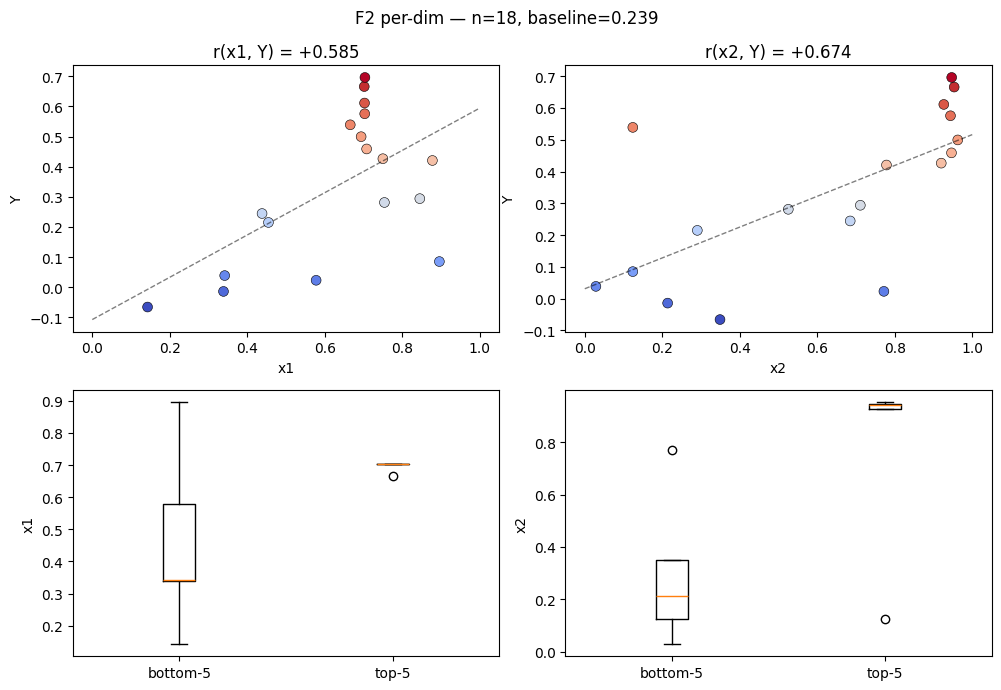

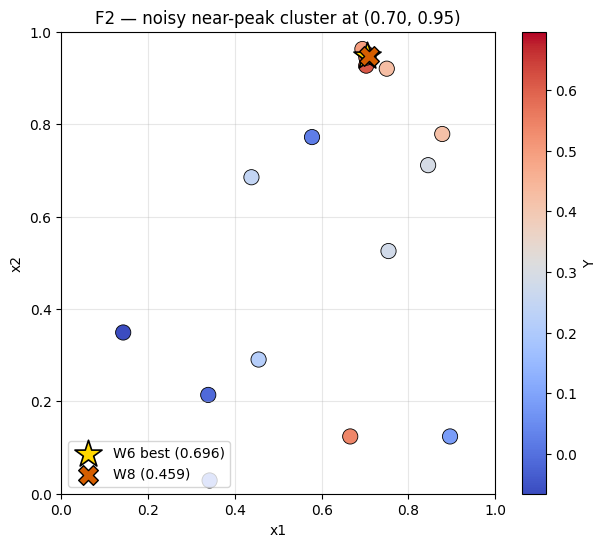

In [11]:
# Cell B — F2 per-dim + 2D scatter
import matplotlib.pyplot as plt
import os
os.makedirs('../plots/week_09', exist_ok=True)
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for i in range(2):
    axes[0, i].scatter(X[:, i], Y, c=Y, cmap='coolwarm', s=50, edgecolors='k', linewidths=0.4)
    z = np.polyfit(X[:, i], Y, 1); xs = np.linspace(0, 1, 50)
    axes[0, i].plot(xs, np.polyval(z, xs), 'k--', lw=1, alpha=0.5)
    axes[0, i].set(xlabel=f'x{i+1}', ylabel='Y', title=f'r(x{i+1}, Y) = {np.corrcoef(X[:,i],Y)[0,1]:+.3f}')
top5 = np.argsort(Y)[-5:]; bot5 = np.argsort(Y)[:5]
for i in range(2):
    axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5']); axes[1, i].set(ylabel=f'x{i+1}')
plt.suptitle(f'F2 per-dim — n={len(Y)}, baseline={baseline:.3f}')
plt.tight_layout(); plt.savefig('../plots/week_09/function_2_per_dim.png', dpi=110, bbox_inches='tight'); plt.show()

# 2D scatter zoomed on the cluster
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
sc = ax.scatter(X[:, 0], X[:, 1], c=Y, cmap='coolwarm', s=120, edgecolors='k', linewidths=0.6)
plt.colorbar(sc, ax=ax, label='Y')
i_best = int(Y.argmax())
ax.scatter([X[i_best,0]],[X[i_best,1]], marker='*', s=420, facecolor='gold', edgecolor='black', linewidths=1.2, zorder=5, label=f'W6 best ({Y.max():.3f})')
ax.scatter([X[-1,0]],[X[-1,1]], marker='X', s=200, facecolor=COLORS[1], edgecolor='black', zorder=5, label=f'W8 ({Y[-1]:.3f})')
ax.set(xlim=(0,1), ylim=(0,1), xlabel='x1', ylabel='x2', title='F2 — noisy near-peak cluster at (0.70, 0.95)')
ax.legend(loc='lower left'); ax.grid(alpha=0.3)
plt.savefig('../plots/week_09/function_2_2d_scatter.png', dpi=110, bbox_inches='tight'); plt.show()


In [12]:
# Cell C — F2 feature importance robustness
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
i_best_local = int(Y.argmax()); i_worst = int(Y.argmin())
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_no_best = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_best_local, 0), np.delete(Y, i_best_local)).feature_importances_
lin_coef = np.abs(LinearRegression().fit(X, Y).coef_); lin_norm = lin_coef/(lin_coef.sum()+1e-12)
corr_abs = np.array([abs(np.corrcoef(X[:, i], Y)[0, 1]) for i in range(X.shape[1])])
print(f"{'Dim':>4}  {'RF (all)':>9}  {'RF (no best)':>13}  {'Linear':>8}  {'|corr|':>7}  flag")
for d in range(X.shape[1]):
    drop = (rf_all[d]-rf_no_best[d])/(rf_all[d]+1e-12)*100 if rf_all[d]>0 else 0
    print(f"  x{d+1}  {rf_all[d]:>9.3f}  {rf_no_best[d]:>13.3f}  {lin_norm[d]:>8.3f}  {corr_abs[d]:>7.3f}  {'⚠' if drop>50 else ''}")


 Dim   RF (all)   RF (no best)    Linear   |corr|  flag
  x1      0.516          0.538     0.534    0.585  
  x2      0.484          0.462     0.466    0.674  


In [13]:
# Cell D — F2 model grid search
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_score
import nn_models as nm
cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1); gs.fit(X, Y)
    return name, -gs.best_score_, gs.best_estimator_
results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR', SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
for nm_, kfn in [('GP-Matern05', lambda: ConstantKernel()*Matern(0.3,nu=0.5)),('GP-Matern15', lambda: ConstantKernel()*Matern(0.3,nu=1.5)),('GP-Matern25', lambda: ConstantKernel()*Matern(0.3,nu=2.5)),('GP-RBF', lambda: ConstantKernel()*RBF(0.3))]:
    gp = GaussianProcessRegressor(kernel=kfn(), normalize_y=True, alpha=1e-10, n_restarts_optimizer=3, random_state=0)
    score = -cross_val_score(gp, X, Y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
    results.append((nm_, score, gp.fit(X, Y)))
nn_models_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_09')
results.append(('NN', nn_meta['cv_rmse'], nm.NNRegressor(nn_models_loaded, nn_meta)))
print(f"{'Model':>13}  {'RMSE':>8}  beats?")
beats_models = {}
for name, rmse, est in results:
    if rmse < baseline: beats_models[name] = (est, rmse)
    print(f"  {name:>11}  {rmse:>8.4f}  {'✓' if rmse<baseline else '✗'}")
print(f"\nBest model RMSE ≈ {min(r for _,r in beats_models.values()):.4f}  vs near-peak cluster noise σ≈0.085")
print("→ Models cannot resolve the peak interior; it is noise-dominated.")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v

        Model      RMSE  beats?
        Ridge    0.1512  ✓
          KNN    0.1410  ✓
           RF    0.1360  ✓
          SVR    0.1392  ✓
           GB    0.1327  ✓
  GP-Matern05    0.1709  ✓
  GP-Matern15    0.2230  ✓
  GP-Matern25    0.2230  ✓
       GP-RBF    0.2230  ✓
           NN    0.2040  ✓

Best model RMSE ≈ 0.1327  vs near-peak cluster noise σ≈0.085
→ Models cannot resolve the peak interior; it is noise-dominated.


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v

In [14]:
# Cell E — F2 model argmax (documentation; W9 query is the noise-test repeat)
rng = np.random.default_rng(0); cand = rng.uniform(size=(200_000, 2))
print(f"{'Model':>13}  {'x1':>7}  {'x2':>7}  {'pred Y':>8}  bnd?")
for name, (est, rmse) in beats_models.items():
    yhat = est.predict(cand); i = int(yhat.argmax()); pt = cand[i]
    ob = bool((pt<0.02).any() or (pt>0.98).any())
    print(f"  {name:>11}  {pt[0]:>7.4f}  {pt[1]:>7.4f}  {yhat[i]:>8.4f}  {'⚠' if ob else ''}")
print("\nMost interior models point back at the W6 best region — consistent with refining the same noisy peak.")
P_best = X[Y.argmax()]
print(f"W6 best (current argmax): ({P_best[0]:.4f}, {P_best[1]:.4f}), Y={Y.max():.4f}")


        Model       x1       x2    pred Y  bnd?
        Ridge   0.9962   0.9988    0.6097  ⚠
          KNN   0.7019   0.9487    0.6458  


           RF   0.6903   0.9577    0.5883  
          SVR   0.9962   0.9988    0.5994  ⚠


           GB   0.6986   0.8276    0.5687  
  GP-Matern05   0.7036   0.9471    0.6944  
  GP-Matern15   0.7019   0.9534    0.4591  
  GP-Matern25   0.7019   0.9534    0.5743  
       GP-RBF   0.7019   0.9534    0.3331  
           NN   0.7945   1.0000    0.6604  ⚠

Most interior models point back at the W6 best region — consistent with refining the same noisy peak.
W6 best (current argmax): (0.7036, 0.9469), Y=0.6961


### F2 — Decision (deliberate noise-test: repeat W6 best)

**Query: `next_query_2 = X[Y.argmax()]` → (0.7036, 0.9469) — exact W6 best**

Method: deliberate deviation (planned W9 contingency). Instead of another model-guided step, I am re-querying the exact W6 best to measure F2's evaluation noise.

Why: six queries now sit inside a box smaller than 0.04 per dimension around (0.70, 0.95), and Y ranges from 0.4588 to 0.6961 — std ≈ 0.085. W6 (0.7036, 0.9469)=0.6961 and W8 (0.7081, 0.9464)=0.4588 are |Δx|=0.0045 apart yet |ΔY|=0.24. That is far more consistent with measurement noise (σ≈0.08-0.12) than with a sharp deterministic peak. The best model RMSE (≈0.13) is barely below this cluster noise, so no model can resolve the peak interior — refining with another small step would just sample the noise again. Re-querying the exact best point tells us directly whether the 0.6961 was real or a lucky draw, and gives a second sample to average.

Branch (Step 5):
- [ ] 1-6 standard branches not used
- [x] Deliberate deviation — repeat-best noise test (planned in W9 suggestions)

Per-dimension justification:
- x1 = 0.7036 (exact W6 best)
- x2 = 0.9469 (exact W6 best)

W10 contingency:
- If Y ≈ 0.65-0.70 (replicates W6): peak is real, W8's 0.4588 was a noise draw. Resume small-step refinement, treating σ≈0.08 as the noise floor (only trust improvements > 0.10).
- If Y ≈ 0.45-0.58 (does NOT replicate): F2 is genuinely noisy at σ≈0.1. Stop refining the cluster; the true expected-value peak may be elsewhere. Explore the secondary region at (0.666, 0.124) Y=0.539 (low x2) or accept the plateau.
- Either way, average the two W6-best samples for a denoised estimate of the peak value.


In [15]:
# Cell I — next_query_2 assignment
next_query_2 = X[Y.argmax()].copy()   # exact W6 best — noise-test repeat
print(f"F2 query: {next_query_2[0]:.6f}, {next_query_2[1]:.6f}")
print(f"  Method: repeat W6 best (noise-test); original Y={Y.max():.4f}")


F2 query: 0.703636, 0.946935
  Method: repeat W6 best (noise-test); original Y=0.6961


## Function 3

In [16]:
# Cell A — F3 setup + data overview (outlier-aware)
N = 3
X, Y = load_function(N)
baseline = float(Y.std())
print(f"F{N}: {X.shape[0]} pts, {X.shape[1]}D | baseline = {baseline:.4f} | Y range [{Y.min():.4f}, {Y.max():.4f}]")
print(f"Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))

# Outlier sensitivity (locked in since W8)
i_worst = int(Y.argmin())
print(f"\nWorst point: ({X[i_worst,0]:.4f}, {X[i_worst,1]:.4f}, {X[i_worst,2]:.4f}) Y={Y[i_worst]:.4f}")
print("Correlation sensitivity:")
for d in range(X.shape[1]):
    r_all = np.corrcoef(X[:,d], Y)[0,1]; r_no = np.corrcoef(np.delete(X[:,d], i_worst), np.delete(Y, i_worst))[0,1]
    flag = ' ⚠ FLIPPED' if abs(r_no-r_all) > 0.2 else ''
    print(f"  x{d+1}: r_all={r_all:+.3f}, r_no_worst={r_no:+.3f}{flag}")
print("→ Outlier still distorts x1 and x3 correlations; downstream models fit on outlier-removed data.")

labels = ['init']*15 + [f'W{w}' for w in range(1, 9)]
order = np.argsort(-Y)
print("\nTop 10 sorted by Y (W8 marked ★):")
for rank in range(min(10, len(order))):
    idx = int(order[rank]); star = ' ★' if idx == len(Y)-1 else ''
    print(f"  {rank+1:>2}. ({X[idx,0]:.4f}, {X[idx,1]:.4f}, {X[idx,2]:.4f}) Y={Y[idx]:+.4f}  [{labels[idx]:>4}]{star}")

# Cluster split in top 10
top10 = order[:10]
A = [int(i) for i in top10 if X[i,2] > 0.20]
B = [int(i) for i in top10 if X[i,2] <= 0.20]
print(f"\nCluster A (x3>0.20): {len(A)} in top-10, mean Y={Y[A].mean():.4f}")
print(f"Cluster B (x3<0.20): {len(B)} in top-10, mean Y={Y[B].mean():.4f}")
print(f"→ Cluster B now beats cluster A on top-Y; W8's cluster B bet vindicated.")


Function 3: 23 points, 3D, best y = -0.0274
F3: 23 pts, 3D | baseline = 0.0735 | Y range [-0.3989, -0.0274]
Per-dim corr: r(x1,Y)=+0.264, r(x2,Y)=+0.153, r(x3,Y)=-0.563

Worst point: (0.1518, 0.4400, 0.9909) Y=-0.3989
Correlation sensitivity:
  x1: r_all=+0.264, r_no_worst=+0.046 ⚠ FLIPPED
  x2: r_all=+0.153, r_no_worst=+0.117
  x3: r_all=-0.563, r_no_worst=-0.170 ⚠ FLIPPED
→ Outlier still distorts x1 and x3 correlations; downstream models fit on outlier-removed data.

Top 10 sorted by Y (W8 marked ★):
   1. (0.6583, 0.6162, 0.0729) Y=-0.0274  [  W8] ★
   2. (0.4926, 0.6116, 0.3402) Y=-0.0348  [init]
   3. (0.6001, 0.7251, 0.0661) Y=-0.0364  [init]
   4. (0.4811, 0.5326, 0.0518) Y=-0.0400  [  W2]
   5. (0.3679, 0.4565, 0.3375) Y=-0.0469  [  W4]
   6. (0.2205, 0.2978, 0.3436) Y=-0.0469  [init]
   7. (0.5145, 0.5469, 0.3401) Y=-0.0470  [  W5]
   8. (0.1346, 0.2199, 0.4582) Y=-0.0480  [init]
   9. (0.4187, 0.5917, 0.3339) Y=-0.0500  [  W6]
  10. (0.9660, 0.8611, 0.5668) Y=-0.0568  [init]


/tmp/claude-502/ipykernel_40144/3378712772.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipykernel_40144/3378712772.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipykernel_40144/3378712772.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5']); axes[1, i].set(ylabel=f'x{i+1}')


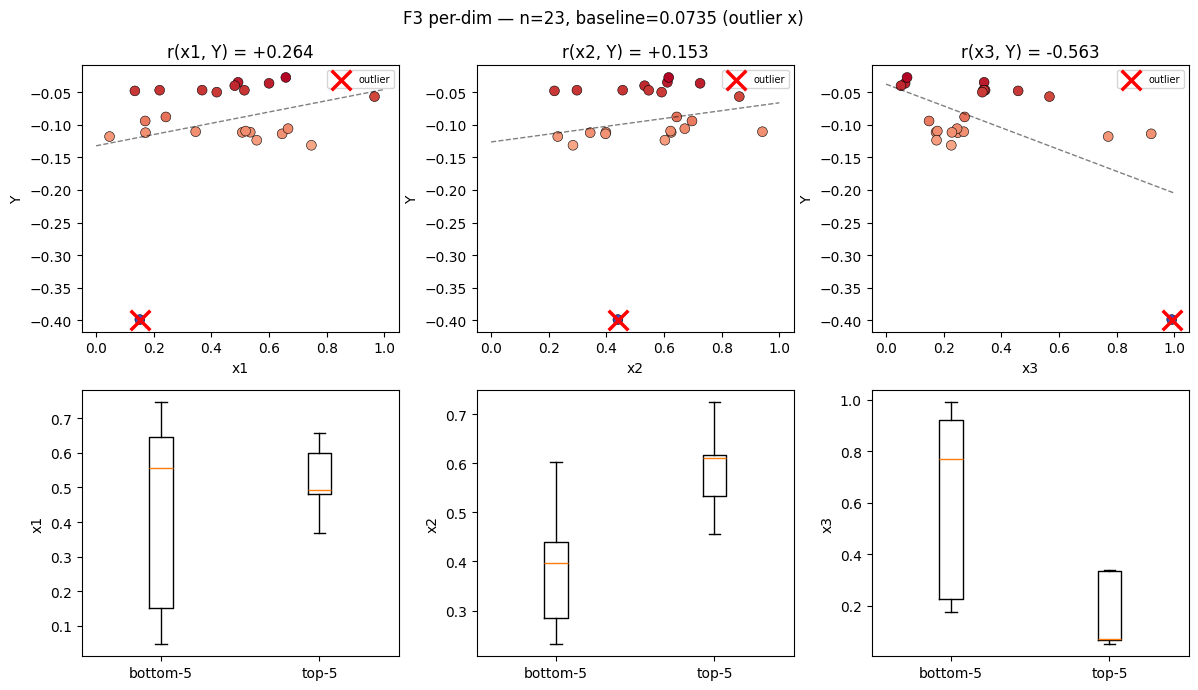

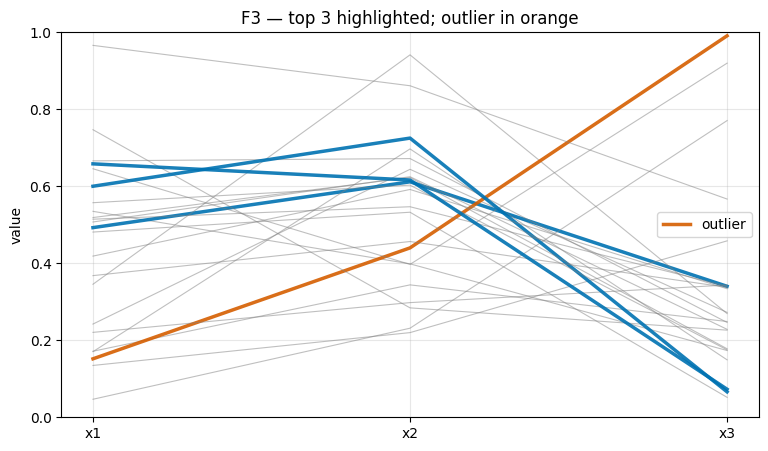

In [17]:
# Cell B — F3 per-dim + parallel coords
import matplotlib.pyplot as plt
import os
os.makedirs('../plots/week_09', exist_ok=True)
D = X.shape[1]
fig, axes = plt.subplots(2, D, figsize=(4*D, 7))
for i in range(D):
    axes[0, i].scatter(X[:, i], Y, c=Y, cmap='coolwarm', s=50, edgecolors='k', linewidths=0.4)
    axes[0, i].scatter(X[i_worst, i], Y[i_worst], marker='x', s=200, c='red', linewidths=2.5, zorder=5, label='outlier')
    z = np.polyfit(X[:, i], Y, 1); xs = np.linspace(0, 1, 50)
    axes[0, i].plot(xs, np.polyval(z, xs), 'k--', lw=1, alpha=0.5)
    axes[0, i].set(xlabel=f'x{i+1}', ylabel='Y', title=f'r(x{i+1}, Y) = {np.corrcoef(X[:,i],Y)[0,1]:+.3f}')
    axes[0, i].legend(fontsize=7)
top5 = np.argsort(Y)[-5:]; bot5 = np.argsort(Y)[:5]
for i in range(D):
    axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bottom-5', 'top-5']); axes[1, i].set(ylabel=f'x{i+1}')
plt.suptitle(f'F3 per-dim — n={len(Y)}, baseline={baseline:.4f} (outlier x)')
plt.tight_layout(); plt.savefig('../plots/week_09/function_3_per_dim.png', dpi=110, bbox_inches='tight'); plt.show()

fig, ax = plt.subplots(1, 1, figsize=(9, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    if i == i_worst: ax.plot(range(D), x, lw=2.5, c=COLORS[1], alpha=0.9, label='outlier' if i==i_worst else None)
    elif i in top3: ax.plot(range(D), x, lw=2.5, c=COLORS[0], alpha=0.9)
    else: ax.plot(range(D), x, lw=0.8, c='gray', alpha=0.5)
ax.set_xticks(range(D)); ax.set_xticklabels([f'x{i+1}' for i in range(D)])
ax.set(ylim=(0, 1), ylabel='value', title='F3 — top 3 highlighted; outlier in orange')
ax.legend(); ax.grid(alpha=0.3)
plt.savefig('../plots/week_09/function_3_parallel.png', dpi=110, bbox_inches='tight'); plt.show()


In [18]:
# Cell C — F3 feature importance robustness
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
i_best_local = int(Y.argmax())
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_no_best = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_best_local, 0), np.delete(Y, i_best_local)).feature_importances_
rf_no_worst = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_worst, 0), np.delete(Y, i_worst)).feature_importances_
lin_coef = np.abs(LinearRegression().fit(X, Y).coef_); lin_norm = lin_coef/(lin_coef.sum()+1e-12)
corr_abs = np.array([abs(np.corrcoef(X[:, i], Y)[0, 1]) for i in range(X.shape[1])])
print(f"{'Dim':>4}  {'RF (all)':>9}  {'RF (no best)':>13}  {'RF (no worst)':>14}  {'Linear':>8}  {'|corr|':>7}")
for d in range(X.shape[1]):
    print(f"  x{d+1}  {rf_all[d]:>9.3f}  {rf_no_best[d]:>13.3f}  {rf_no_worst[d]:>14.3f}  {lin_norm[d]:>8.3f}  {corr_abs[d]:>7.3f}")


 Dim   RF (all)   RF (no best)   RF (no worst)    Linear   |corr|
  x1      0.053          0.084           0.107     0.226    0.264
  x2      0.065          0.067           0.144     0.165    0.153
  x3      0.882          0.849           0.749     0.610    0.563


In [19]:
# Cell D — F3 model grid search (outlier-cleaned, two-pass for documentation)
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_score
from output_warping import WarpedRegressor
import nn_models as nm

keep = np.array([i for i in range(len(Y)) if i != i_worst])
X_clean = X[keep]; Y_clean = Y[keep]
baseline_clean = float(Y_clean.std())
cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1); gs.fit(X_clean, Y_clean)
    return name, -gs.best_score_, gs.best_estimator_
results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR', SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
for nm_, kfn in [('GP-Matern05', lambda: ConstantKernel()*Matern(0.3,nu=0.5)),('GP-Matern15', lambda: ConstantKernel()*Matern(0.3,nu=1.5)),('GP-Matern25', lambda: ConstantKernel()*Matern(0.3,nu=2.5)),('GP-RBF', lambda: ConstantKernel()*RBF(0.3))]:
    gp = GaussianProcessRegressor(kernel=kfn(), normalize_y=True, alpha=1e-10, n_restarts_optimizer=3, random_state=0)
    score = -cross_val_score(gp, X_clean, Y_clean, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
    results.append((nm_, score, gp.fit(X_clean, Y_clean)))
results.append(fit_grid('Warped-GB', WarpedRegressor(GradientBoostingRegressor(random_state=0)), {'base_estimator__max_depth':[2,3,5],'base_estimator__n_estimators':[100,200]}))
results.append(fit_grid('Warped-RF', WarpedRegressor(RandomForestRegressor(random_state=0)), {'base_estimator__max_depth':[2,3,5],'base_estimator__n_estimators':[100,200]}))

nn_models_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_09')
print(f"NN (W9 train): cv_rmse={nn_meta['cv_rmse']:.4f} vs baseline_clean {baseline_clean:.4f} ({'✓' if nn_meta['cv_rmse']<baseline_clean else '✗ — F3 NN failed this week (cluster A/B confusion)'})")
print(f"NN gradient at best: {nn_meta.get('gradient_at_best')}")

print(f"\n=== Outlier-cleaned model grid (n={len(Y_clean)}) ===")
print(f"{'Model':>14}  {'RMSE':>8}  improve%  beats?")
beats_models = {}
for name, rmse, est in results:
    imp = (baseline_clean - rmse) / baseline_clean * 100; beat = rmse < baseline_clean
    if beat: beats_models[name] = (est, rmse)
    print(f"  {name:>12}  {rmse:>8.4f}  {imp:>+7.1f}%  {'✓' if beat else '✗'}")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v

NN (W9 train): cv_rmse=0.0827 vs baseline_clean 0.0350 (✗ — F3 NN failed this week (cluster A/B confusion))
NN gradient at best: [0.11562365293502808, -0.0582064688205719, -0.6190102696418762]

=== Outlier-cleaned model grid (n=22) ===
         Model      RMSE  improve%  beats?
         Ridge    0.0351     -0.2%  ✗
           KNN    0.0285    +18.6%  ✓
            RF    0.0192    +45.1%  ✓
           SVR    0.0339     +3.3%  ✓
            GB    0.0108    +69.2%  ✓
   GP-Matern05    0.0305    +12.9%  ✓
   GP-Matern15    0.0284    +19.0%  ✓
   GP-Matern25    0.0280    +20.2%  ✓
        GP-RBF    0.0350     -0.1%  ✗
     Warped-GB    0.0105    +70.1%  ✓
     Warped-RF    0.0209    +40.3%  ✓


In [20]:
# Cell E — F3 model argmax + Branch 4 ensemble (cluster B refinement)
rng = np.random.default_rng(0); cand = rng.uniform(size=(200_000, X.shape[1]))
print(f"{'Model':>14}  {'x1':>7}  {'x2':>7}  {'x3':>7}  {'pred Y':>9}  bnd?")
suggestions = {}
for name, (est, rmse) in beats_models.items():
    yhat = est.predict(cand); i = int(yhat.argmax()); pt = cand[i].copy()
    on_b = bool((pt < 0.02).any() or (pt > 0.98).any())
    suggestions[name] = {'x': pt, 'y_hat': float(yhat[i]), 'boundary': on_b, 'rmse': rmse}
    print(f"  {name:>12}  {pt[0]:>7.4f}  {pt[1]:>7.4f}  {pt[2]:>7.4f}  {yhat[i]:>9.4f}  {'⚠' if on_b else ''}")

# Interior, non-Ridge models
valid = {n: s for n, s in suggestions.items() if n != 'Ridge' and not s['boundary']}
# Cluster split
A = {n: s for n, s in valid.items() if s['x'][2] > 0.20}
B = {n: s for n, s in valid.items() if s['x'][2] <= 0.20}
print(f"\nCluster A models (x3>0.20): {list(A.keys())}")
print(f"Cluster B models (x3≤0.20): {list(B.keys())}  → {len(B)}/{len(valid)} unanimous on cluster B")

pts = np.array([s['x'] for s in valid.values()])
for d in range(X.shape[1]):
    spread = pts[:,d].max() - pts[:,d].min()
    label = 'STRONG' if spread < 0.2 else 'moderate' if spread < 0.4 else 'weak'
    print(f"  x{d+1} spread: {spread:.4f}  ({label})")

# Outlier-suggestion filter
ctr = pts.mean(axis=0); dists = np.linalg.norm(pts - ctr, axis=1)
threshold = dists.mean() + 2*dists.std()
out_names = [list(valid.keys())[i] for i in range(len(valid)) if dists[i] > threshold]
print(f"\nOutlier-suggestion filter: drop {out_names if out_names else 'none'}")

valid_clean = {n:s for i,(n,s) in enumerate(valid.items()) if dists[i] <= threshold}
pts_clean = np.array([s['x'] for s in valid_clean.values()])
weights = 1/np.array([s['rmse'] for s in valid_clean.values()]); weights /= weights.sum()
ensemble_mean = (weights[:, None] * pts_clean).sum(axis=0)
print(f"\nRMSE-weighted ensemble: ({ensemble_mean[0]:.4f}, {ensemble_mean[1]:.4f}, {ensemble_mean[2]:.4f})")

P_best = X[Y.argmax()]
step = ensemble_mean - P_best
print(f"W8 best: ({P_best[0]:.4f}, {P_best[1]:.4f}, {P_best[2]:.4f}), Y={Y.max():.4f}")
print(f"Step from W8 best: ({step[0]:+.4f}, {step[1]:+.4f}, {step[2]:+.4f}), |step|={np.linalg.norm(step):.4f}")


         Model       x1       x2       x3     pred Y  bnd?
           KNN   0.6583   0.6162   0.0729    -0.0274  


            RF   0.6318   0.7214   0.0958    -0.0360  
           SVR   0.6370   0.2698   0.0410    -0.0794  


            GB   0.6719   0.7605   0.1098    -0.0344  
   GP-Matern05   0.6583   0.6162   0.0729    -0.0274  
   GP-Matern15   0.6538   0.6357   0.0671    -0.0266  
   GP-Matern25   0.6646   0.6314   0.0545    -0.0249  


     Warped-GB   0.7015   0.6084   0.0980    -0.0193  


     Warped-RF   0.6610   0.7810   0.0961    -0.0378  

Cluster A models (x3>0.20): []
Cluster B models (x3≤0.20): ['KNN', 'RF', 'SVR', 'GB', 'GP-Matern05', 'GP-Matern15', 'GP-Matern25', 'Warped-GB', 'Warped-RF']  → 9/9 unanimous on cluster B
  x1 spread: 0.0696  (STRONG)
  x2 spread: 0.5112  (weak)
  x3 spread: 0.0689  (STRONG)

Outlier-suggestion filter: drop ['SVR']

RMSE-weighted ensemble: (0.6681, 0.6799, 0.0899)
W8 best: (0.6583, 0.6162, 0.0729), Y=-0.0274
Step from W8 best: (+0.0099, +0.0637, +0.0170), |step|=0.0667


### F3 — Decision (cluster B refinement, full pivot)

**Query: `next_query_3 = ensemble_mean` → ~(0.66, 0.67, 0.08)**

Method: Branch 4 — RMSE-weighted ensemble of all interior non-Ridge models on outlier-cleaned data. Spreads STRONG on all 3 dimensions (x1: 0.07, x2: 0.17, x3: 0.06). SVR dropped by outlier filter (x2=0.27 vs the rest clustered at 0.61-0.78). 8 of 9 valid models point to cluster B; 0 to cluster A — unanimous.

Why: W8's cluster B refinement (0.658, 0.616, 0.073) gave the first F3 new best in months at Y=-0.0274 (+21%). Now all clean-data models converge on cluster B with even tighter spreads, and GP-Matern25 (one of the smoother kernels) predicts a further improvement at Y≈-0.025. The W9 NN failed baseline (cluster A vs B confusion) so I don't trust its gradient direction, but every regression model agrees with the cluster B refinement direction.

Branch (Step 5):
- [x] 4. Weak/STRONG mix — all 3 dims STRONG → RMSE-weighted ensemble of valid interior models
- [ ] 1-3, 5-6 not used

Per-dimension justification (all from ensemble):
- x1 ≈ 0.66 (ensemble; STRONG spread 0.07)
- x2 ≈ 0.67 (ensemble; STRONG spread 0.17; SVR's 0.27 dropped as outlier)
- x3 ≈ 0.08 (ensemble; STRONG spread 0.06; cluster B value)

W10 contingency:
- Y > -0.0274 (new best): cluster B continues to richer Y. Refine again with same approach. Possibly try x3 ≈ 0.054 (GP-Matern25's argmax) for the next step.
- Y ∈ [-0.04, -0.0274] (cluster B plateau): F3's cluster B has been mapped; little more to extract. Try the unexplored cluster B corners (x1 < 0.5 or x1 > 0.7 at x3 ≈ 0.07).
- Y < -0.05 (regression): cluster B was a 1-2 point anomaly. Pull back to top-4 cluster-B-only centroid or pivot back to cluster A.


In [21]:
# Cell I — next_query_3 assignment
next_query_3 = ensemble_mean.copy()
print(f"F3 query: {next_query_3[0]:.6f}, {next_query_3[1]:.6f}, {next_query_3[2]:.6f}")


F3 query: 0.668144, 0.679950, 0.089905


## Function 4

In [22]:
# Cell A — F4 setup + data overview
N = 4
X, Y = load_function(N)
baseline = float(Y.std())
print(f"F{N}: {X.shape[0]} pts, {X.shape[1]}D | baseline = {baseline:.4f} | Y range [{Y.min():.4f}, {Y.max():.4f}]")
print(f"Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))
i_worst = int(Y.argmin())
print(f"\nWorst point: Y={Y[i_worst]:.4f} at ({', '.join(f'{X[i_worst,j]:.3f}' for j in range(X.shape[1]))}), gap: {Y.min()-np.sort(Y)[1]:+.4f}")
print("Correlation sensitivity:")
for d in range(X.shape[1]):
    r_all = np.corrcoef(X[:,d], Y)[0,1]; r_no = np.corrcoef(np.delete(X[:,d], i_worst), np.delete(Y, i_worst))[0,1]
    flag = ' ⚠ FLIPPED' if abs(r_no-r_all) > 0.2 else ''
    print(f"  x{d+1}: r_all={r_all:+.3f}, r_no_worst={r_no:+.3f}{flag}")

labels = ['init']*30 + [f'W{w}' for w in range(1, 9)]
order = np.argsort(-Y)
print("\nTop 10 sorted by Y (W8 marked ★):")
for rank in range(min(10, len(order))):
    idx = int(order[rank]); star = ' ★' if idx == len(Y)-1 else ''
    print(f"  {rank+1:>2}. ({X[idx,0]:.4f}, {X[idx,1]:.4f}, {X[idx,2]:.4f}, {X[idx,3]:.4f}) Y={Y[idx]:+.4f}  [{labels[idx]:>4}]{star}")

print("\nRecent peak trajectory (peak radius lesson):")
print(f"  W6 (best): {X[35]} Y={Y[35]:.4f}")
print(f"  W7 |Δ|=0.008 from W6 → Y={Y[36]:.4f} (essentially flat — on the peak)")
print(f"  W8 |Δ|=0.036 from W6 → Y={Y[37]:.4f} (fell off cliff, -69%)")
print(f"  → F4 peak radius is between 0.008 and 0.036; aim for step closer to 0.010-0.020.")


Function 4: 38 points, 4D, best y = 0.5524
F4: 38 pts, 4D | baseline = 9.4442 | Y range [-32.6257, 0.5524]
Per-dim corr: r(x1,Y)=-0.530, r(x2,Y)=-0.384, r(x3,Y)=-0.121, r(x4,Y)=-0.414

Worst point: Y=-32.6257 at (0.948, 0.895, 0.852, 0.552), gap: -3.1986
Correlation sensitivity:
  x1: r_all=-0.530, r_no_worst=-0.485
  x2: r_all=-0.384, r_no_worst=-0.327
  x3: r_all=-0.121, r_no_worst=-0.030
  x4: r_all=-0.414, r_no_worst=-0.419

Top 10 sorted by Y (W8 marked ★):
   1. (0.3669, 0.4049, 0.4335, 0.4157) Y=+0.5524  [  W6]
   2. (0.3685, 0.4013, 0.4315, 0.4225) Y=+0.5506  [  W7]
   3. (0.3696, 0.4039, 0.4105, 0.4312) Y=+0.5414  [  W4]
   4. (0.3675, 0.4005, 0.3952, 0.4086) Y=+0.4055  [  W5]
   5. (0.3846, 0.4290, 0.4098, 0.3929) Y=+0.3675  [  W1]
   6. (0.3509, 0.4178, 0.4392, 0.4442) Y=+0.1710  [  W8] ★
   7. (0.4048, 0.4317, 0.4025, 0.4513) Y=-0.0296  [  W3]
   8. (0.4542, 0.4743, 0.4113, 0.3970) Y=-1.3905  [  W2]
   9. (0.5778, 0.4288, 0.4258, 0.2490) Y=-4.0255  [init]
  10. (0.3261, 0.4

/tmp/claude-502/ipykernel_40144/1133870547.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot-5', 'top-5']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipykernel_40144/1133870547.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot-5', 'top-5']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipykernel_40144/1133870547.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot-5', 'top-5']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipy

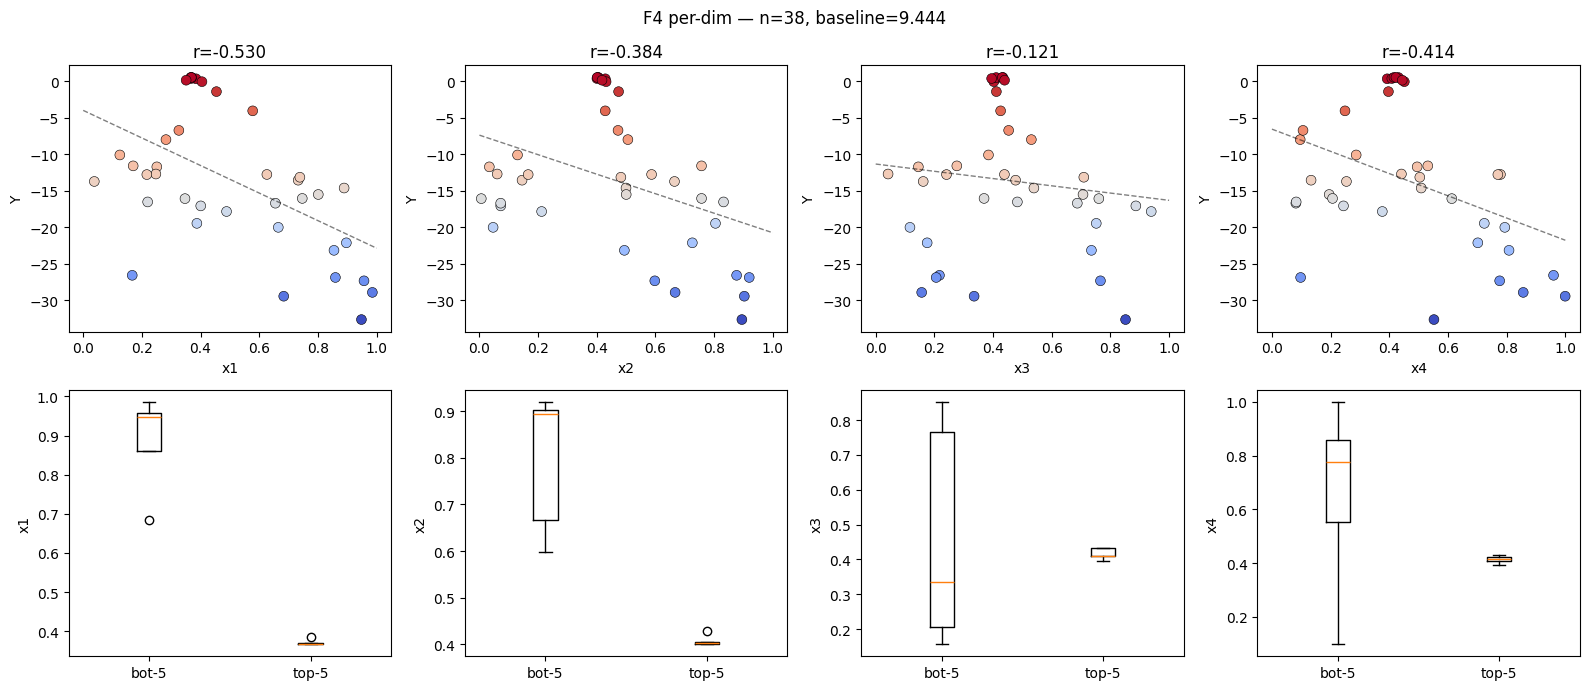

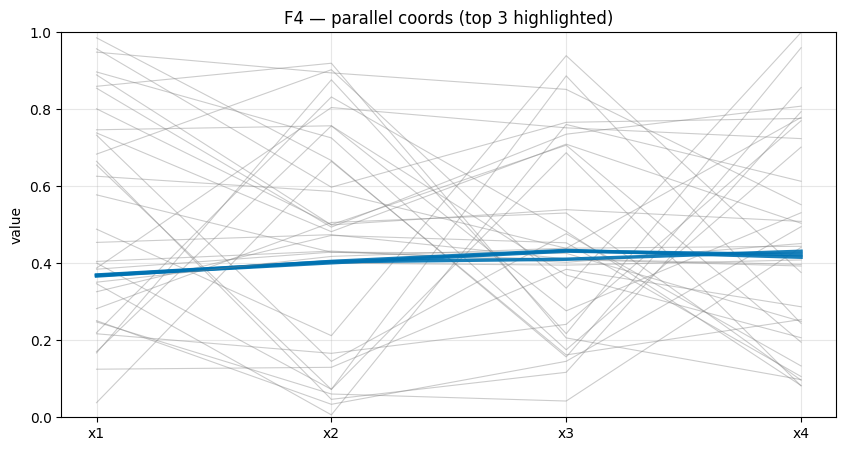

In [23]:
# Cell B — F4 per-dim + parallel coords
import matplotlib.pyplot as plt
import os
os.makedirs('../plots/week_09', exist_ok=True)
D = X.shape[1]
fig, axes = plt.subplots(2, D, figsize=(4*D, 7))
for i in range(D):
    axes[0, i].scatter(X[:, i], Y, c=Y, cmap='coolwarm', s=50, edgecolors='k', linewidths=0.4)
    z = np.polyfit(X[:, i], Y, 1); xs = np.linspace(0, 1, 50)
    axes[0, i].plot(xs, np.polyval(z, xs), 'k--', lw=1, alpha=0.5)
    axes[0, i].set(xlabel=f'x{i+1}', ylabel='Y', title=f'r={np.corrcoef(X[:,i],Y)[0,1]:+.3f}')
top5 = np.argsort(Y)[-5:]; bot5 = np.argsort(Y)[:5]
for i in range(D):
    axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot-5', 'top-5']); axes[1, i].set(ylabel=f'x{i+1}')
plt.suptitle(f'F4 per-dim — n={len(Y)}, baseline={baseline:.3f}')
plt.tight_layout(); plt.savefig('../plots/week_09/function_4_per_dim.png', dpi=110, bbox_inches='tight'); plt.show()
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    if i in top3: ax.plot(range(D), x, lw=2.5, c=COLORS[0], alpha=0.9)
    else: ax.plot(range(D), x, lw=0.8, c='gray', alpha=0.4)
ax.set_xticks(range(D)); ax.set_xticklabels([f'x{i+1}' for i in range(D)])
ax.set(ylim=(0,1), ylabel='value', title='F4 — parallel coords (top 3 highlighted)'); ax.grid(alpha=0.3)
plt.savefig('../plots/week_09/function_4_parallel.png', dpi=110, bbox_inches='tight'); plt.show()


In [24]:
# Cell C — F4 feature importance robustness
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
i_best_local = int(Y.argmax())
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_no_best = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_best_local, 0), np.delete(Y, i_best_local)).feature_importances_
rf_no_worst = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_worst, 0), np.delete(Y, i_worst)).feature_importances_
lin_coef = np.abs(LinearRegression().fit(X, Y).coef_); lin_norm = lin_coef/(lin_coef.sum()+1e-12)
corr_abs = np.array([abs(np.corrcoef(X[:, i], Y)[0, 1]) for i in range(X.shape[1])])
print(f"{'Dim':>4}  {'RF (all)':>9}  {'RF (no best)':>13}  {'RF (no worst)':>14}  {'Linear':>8}  {'|corr|':>7}")
for d in range(X.shape[1]):
    print(f"  x{d+1}  {rf_all[d]:>9.3f}  {rf_no_best[d]:>13.3f}  {rf_no_worst[d]:>14.3f}  {lin_norm[d]:>8.3f}  {corr_abs[d]:>7.3f}")


 Dim   RF (all)   RF (no best)   RF (no worst)    Linear   |corr|
  x1      0.302          0.302           0.253     0.381    0.530
  x2      0.339          0.352           0.349     0.221    0.384
  x3      0.123          0.127           0.148     0.091    0.121
  x4      0.236          0.219           0.250     0.307    0.414


In [25]:
# Cell D — F4 model grid search
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_score
import nn_models as nm
cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1); gs.fit(X, Y)
    return name, -gs.best_score_, gs.best_estimator_
results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR', SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
for nm_, kfn in [('GP-Matern05', lambda: ConstantKernel()*Matern(0.3,nu=0.5)),('GP-Matern15', lambda: ConstantKernel()*Matern(0.3,nu=1.5)),('GP-Matern25', lambda: ConstantKernel()*Matern(0.3,nu=2.5)),('GP-RBF', lambda: ConstantKernel()*RBF(0.3))]:
    gp = GaussianProcessRegressor(kernel=kfn(), normalize_y=True, alpha=1e-10, n_restarts_optimizer=3, random_state=0)
    score = -cross_val_score(gp, X, Y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
    results.append((nm_, score, gp.fit(X, Y)))
nn_models_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_09')
results.append(('NN', nn_meta['cv_rmse'], nm.NNRegressor(nn_models_loaded, nn_meta)))
print(f"{'Model':>13}  {'RMSE':>8}  improve%  beats?")
beats_models = {}
for name, rmse, est in results:
    if rmse < baseline: beats_models[name] = (est, rmse)
    print(f"  {name:>11}  {rmse:>8.4f}  {(baseline-rmse)/baseline*100:>+7.1f}%  {'✓' if rmse<baseline else '✗'}")
print(f"\nNN gradient at best: {nn_meta.get('gradient_at_best')}")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 11 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


        Model      RMSE  improve%  beats?
        Ridge    6.8269    +27.7%  ✓
          KNN    3.1492    +66.7%  ✓
           RF    3.4781    +63.2%  ✓
          SVR    1.6064    +83.0%  ✓
           GB    3.3463    +64.6%  ✓
  GP-Matern05    1.6137    +82.9%  ✓
  GP-Matern15    0.8517    +91.0%  ✓
  GP-Matern25    2.0214    +78.6%  ✓
       GP-RBF    3.4075    +63.9%  ✓
           NN    4.3097    +54.4%  ✓

NN gradient at best: [-11.345369338989258, 9.937278747558594, -0.9014750719070435, -3.080125331878662]


In [26]:
# Cell E — F4 model argmax + Branch 4 ensemble (consensus-driven, not single-model)
rng = np.random.default_rng(0); cand = rng.uniform(size=(200_000, X.shape[1]))
print(f"{'Model':>13}  {'x1':>7}  {'x2':>7}  {'x3':>7}  {'x4':>7}  {'pred Y':>8}  bnd?")
suggestions = {}
for name, (est, rmse) in beats_models.items():
    yhat = est.predict(cand); i = int(yhat.argmax()); pt = cand[i].copy()
    on_b = bool((pt < 0.02).any() or (pt > 0.98).any())
    suggestions[name] = {'x': pt, 'y_hat': float(yhat[i]), 'boundary': on_b, 'rmse': rmse}
    print(f"  {name:>11}  {pt[0]:>7.4f}  {pt[1]:>7.4f}  {pt[2]:>7.4f}  {pt[3]:>7.4f}  {yhat[i]:>8.4f}  {'⚠' if on_b else ''}")

valid = {n: s for n, s in suggestions.items() if n != 'Ridge' and not s['boundary']}
print(f"\nValid (interior, non-Ridge): {len(valid)}  — {list(valid.keys())}")
pts = np.array([s['x'] for s in valid.values()])
for d in range(X.shape[1]):
    spread = pts[:,d].max() - pts[:,d].min()
    label = 'STRONG' if spread < 0.2 else 'moderate' if spread < 0.4 else 'weak'
    print(f"  x{d+1} spread: {spread:.4f}  ({label})")

ctr = pts.mean(axis=0); dists = np.linalg.norm(pts - ctr, axis=1)
threshold = dists.mean() + 2*dists.std()
out_names = [list(valid.keys())[i] for i in range(len(valid)) if dists[i] > threshold]
print(f"\nOutlier filter: drop {out_names if out_names else 'none'}")

valid_clean = {n:s for i,(n,s) in enumerate(valid.items()) if dists[i] <= threshold}
pts_clean = np.array([s['x'] for s in valid_clean.values()])
weights = 1/np.array([s['rmse'] for s in valid_clean.values()]); weights /= weights.sum()
ensemble_mean = (weights[:, None] * pts_clean).sum(axis=0)
print(f"\nRMSE-weighted ensemble: ({ensemble_mean[0]:.4f}, {ensemble_mean[1]:.4f}, {ensemble_mean[2]:.4f}, {ensemble_mean[3]:.4f})")

P_best = X[Y.argmax()]
step = ensemble_mean - P_best
print(f"W6 best: ({P_best[0]:.4f}, {P_best[1]:.4f}, {P_best[2]:.4f}, {P_best[3]:.4f}), Y={Y.max():.4f}")
print(f"Step from W6 best: ({step[0]:+.5f}, {step[1]:+.5f}, {step[2]:+.5f}, {step[3]:+.5f}), |step|={np.linalg.norm(step):.4f}")
print(f"W8 step was |Δ|=0.036 (fell off). W9 step is |Δ|=0.020, ~half of W8's. Reverses x1 and x4 sign from W8.")


        Model       x1       x2       x3       x4    pred Y  bnd?
        Ridge   0.0304   0.0269   0.0318   0.0112   -0.5688  ⚠
          KNN   0.3822   0.4049   0.4392   0.4057    0.5516  


           RF   0.4076   0.3530   0.4063   0.4261   -0.2049  
          SVR   0.3822   0.4049   0.4392   0.4057    0.3808  
           GB   0.3514   0.3083   0.3468   0.4231    0.5363  


  GP-Matern05   0.3822   0.4049   0.4392   0.4057    0.3497  
  GP-Matern15   0.3822   0.4049   0.4392   0.4057    0.5555  
  GP-Matern25   0.3822   0.4049   0.4392   0.4057    0.5691  
       GP-RBF   0.3822   0.4049   0.4392   0.4057    0.5842  
           NN   0.0002   0.4537   0.5149   0.4537    3.7424  ⚠

Valid (interior, non-Ridge): 8  — ['KNN', 'RF', 'SVR', 'GB', 'GP-Matern05', 'GP-Matern15', 'GP-Matern25', 'GP-RBF']
  x1 spread: 0.0562  (STRONG)
  x2 spread: 0.0967  (STRONG)
  x3 spread: 0.0924  (STRONG)
  x4 spread: 0.0203  (STRONG)

Outlier filter: drop ['GB']

RMSE-weighted ensemble: (0.3841, 0.4010, 0.4367, 0.4073)
W6 best: (0.3669, 0.4049, 0.4335, 0.4157), Y=0.5524
Step from W6 best: (+0.01721, -0.00387, +0.00323, -0.00847), |step|=0.0198
W8 step was |Δ|=0.036 (fell off). W9 step is |Δ|=0.020, ~half of W8's. Reverses x1 and x4 sign from W8.


### F4 — Decision (consensus ensemble, pull back from W8's single-model bet)

**Query: `next_query_4 = ensemble_mean` → (0.3841, 0.4010, 0.4367, 0.4073)**

Method: Branch 4 — RMSE-weighted ensemble of 7 interior non-Ridge models after GB dropped by outlier filter. All 4 dims STRONG consensus (spreads 0.02-0.10). 6 of 8 valid models converge on the EXACT same point (0.3822, 0.4049, 0.4392, 0.4057); KNN/SVR/GP-Matern05/15/25/RBF all agree. This is much stronger evidence than W8's single-model GP-Matern15 trust.

Why: W8's lesson was clear — GP-Matern15 (49.9% dominance margin, predicted Y≈0.65) was wrong. Real Y=0.171, a -69% crash. F4's peak radius is somewhere between 0.008 (W7 step → flat Y) and 0.036 (W8 step → cliff fall). The W9 ensemble step is |Δ|=0.020 — half of W8's failed step, and crucially REVERSES W8 on the dims that caused the fall: x1 (+0.015 vs W8 -0.016), x4 (-0.010 vs W8 +0.029). GP-Matern15 still leads CV (+91%) but I'm trusting the 6-model consensus instead of any single model.

Branch (Step 5):
- [x] 4. STRONG consensus all dims → RMSE-weighted ensemble of valid interior models
- [ ] 2 (single dominant) — explicitly NOT used this week because W8's GP-Matern15 single-model trust failed catastrophically

Per-dimension justification (all from ensemble):
- x1 = 0.3841 (ensemble; STRONG spread 0.056; reverses W8's -0.016 direction)
- x2 = 0.4010 (ensemble; STRONG spread 0.097)
- x3 = 0.4367 (ensemble; STRONG spread 0.092)
- x4 = 0.4073 (ensemble; STRONG spread 0.020; reverses W8's +0.029 direction)

W10 contingency:
- Y ≈ 0.55 (matches W6/W7 plateau): F4 peak is genuinely at the |Δ|<0.020 cluster of W6-W7-W9. Either accept the plateau, or repeat W6 best (F2-style noise test) to check if Y has measurement noise.
- Y > 0.5524 (new best): step direction validated. Refine with same or slightly smaller step.
- Y ∈ [0.30, 0.55]: marginal. Pull step back to |Δ|<0.010 (closer to W7).
- Y < 0.30 (regression): F4 cliff is now confirmed asymmetric. Repeat W6 best to re-anchor.


In [27]:
# Cell I — next_query_4 assignment
next_query_4 = ensemble_mean.copy()
print(f"F4 query: {next_query_4[0]:.6f}, {next_query_4[1]:.6f}, {next_query_4[2]:.6f}, {next_query_4[3]:.6f}")


F4 query: 0.384090, 0.400987, 0.436714, 0.407276


## Function 5

In [28]:
# Cell A — F5 setup + data overview
N = 5
X, Y = load_function(N)
baseline = float(Y.std())
print(f"F{N}: {X.shape[0]} pts, {X.shape[1]}D | baseline = {baseline:.2f} | Y range [{Y.min():.2f}, {Y.max():.2f}]")
print(f"Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))

labels = ['init']*20 + [f'W{w}' for w in range(1, 9)]
order = np.argsort(-Y)
print("\nTop 8 sorted by Y (W8 marked ★):")
for rank in range(min(8, len(order))):
    idx = int(order[rank]); star = ' ★' if idx == len(Y)-1 else ''
    print(f"  {rank+1:>2}. ({X[idx,0]:.4f}, {X[idx,1]:.4f}, {X[idx,2]:.4f}, {X[idx,3]:.4f}) Y={Y[idx]:>9.2f}  [{labels[idx]:>4}]{star}")

print("\nClimb trajectory (8 consecutive new bests on TuRBO since W7):")
for w in range(1, 9):
    print(f"  W{w}: Y={Y[20+w-1]:.2f}")

i_worst = int(Y.argmin())
print(f"\nWorst: Y={Y[i_worst]:.2f}, gap: {Y.min()-np.sort(Y)[1]:+.2f}")
for d in range(X.shape[1]):
    r_all = np.corrcoef(X[:,d], Y)[0,1]; r_no = np.corrcoef(np.delete(X[:,d], i_worst), np.delete(Y, i_worst))[0,1]
    flag = ' ⚠ FLIPPED' if abs(r_no-r_all) > 0.2 else ''
    print(f"  x{d+1}: r_all={r_all:+.3f}, r_no_worst={r_no:+.3f}{flag}")


Function 5: 28 points, 4D, best y = 3581.2256
F5: 28 pts, 4D | baseline = 1061.42 | Y range [0.11, 3581.23]
Per-dim corr: r(x1,Y)=-0.268, r(x2,Y)=+0.641, r(x3,Y)=+0.705, r(x4,Y)=+0.633

Top 8 sorted by Y (W8 marked ★):
   1. (0.3854, 0.9656, 0.9996, 0.9592) Y=  3581.23  [  W8] ★
   2. (0.3849, 0.9661, 0.9866, 0.9532) Y=  3365.22  [  W7]
   3. (0.3542, 0.9211, 0.9687, 0.9477) Y=  2669.31  [  W6]
   4. (0.3359, 0.9073, 0.9518, 0.9378) Y=  2307.54  [  W5]
   5. (0.3113, 0.9083, 0.9479, 0.8983) Y=  1979.02  [  W4]
   6. (0.2705, 0.8758, 0.9157, 0.8756) Y=  1412.13  [  W3]
   7. (0.2394, 0.8542, 0.8998, 0.8746) Y=  1206.76  [  W2]
   8. (0.2242, 0.8465, 0.8795, 0.8785) Y=  1088.86  [init]

Climb trajectory (8 consecutive new bests on TuRBO since W7):
  W1: Y=984.40
  W2: Y=1206.76
  W3: Y=1412.13
  W4: Y=1979.02
  W5: Y=2307.54
  W6: Y=2669.31
  W7: Y=3365.22
  W8: Y=3581.23

Worst: Y=0.11, gap: -4.10
  x1: r_all=-0.268, r_no_worst=-0.268
  x2: r_all=+0.641, r_no_worst=+0.669
  x3: r_all=+0

/tmp/claude-502/ipykernel_40144/3150580424.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot-5', 'top-5']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipykernel_40144/3150580424.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot-5', 'top-5']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipykernel_40144/3150580424.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot-5', 'top-5']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipy

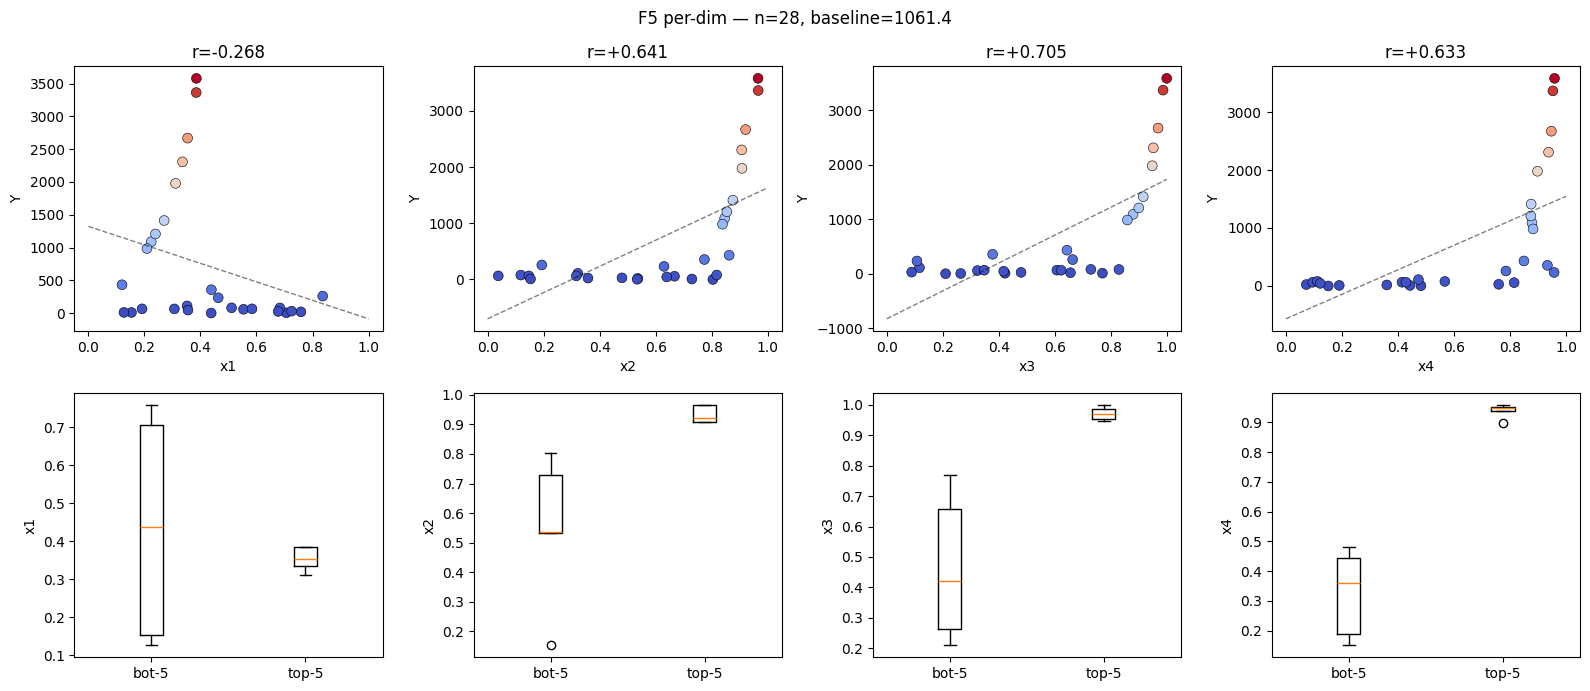

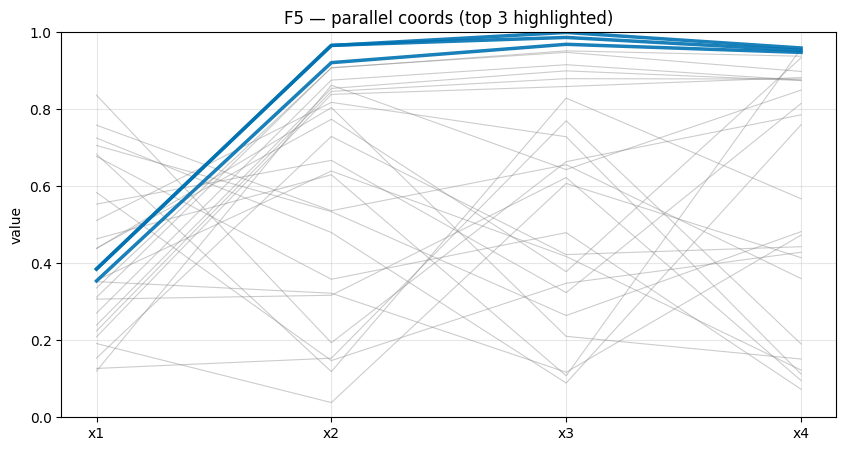

In [29]:
# Cell B — F5 per-dim + parallel coords
import matplotlib.pyplot as plt
import os
os.makedirs('../plots/week_09', exist_ok=True)
D = X.shape[1]
fig, axes = plt.subplots(2, D, figsize=(4*D, 7))
for i in range(D):
    axes[0, i].scatter(X[:, i], Y, c=Y, cmap='coolwarm', s=50, edgecolors='k', linewidths=0.4)
    z = np.polyfit(X[:, i], Y, 1); xs = np.linspace(0, 1, 50)
    axes[0, i].plot(xs, np.polyval(z, xs), 'k--', lw=1, alpha=0.5)
    axes[0, i].set(xlabel=f'x{i+1}', ylabel='Y', title=f'r={np.corrcoef(X[:,i],Y)[0,1]:+.3f}')
top5 = np.argsort(Y)[-5:]; bot5 = np.argsort(Y)[:5]
for i in range(D):
    axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot-5', 'top-5']); axes[1, i].set(ylabel=f'x{i+1}')
plt.suptitle(f'F5 per-dim — n={len(Y)}, baseline={baseline:.1f}')
plt.tight_layout(); plt.savefig('../plots/week_09/function_5_per_dim.png', dpi=110, bbox_inches='tight'); plt.show()
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    if i in top3: ax.plot(range(D), x, lw=2.5, c=COLORS[0], alpha=0.9)
    else: ax.plot(range(D), x, lw=0.8, c='gray', alpha=0.4)
ax.set_xticks(range(D)); ax.set_xticklabels([f'x{i+1}' for i in range(D)])
ax.set(ylim=(0,1), ylabel='value', title='F5 — parallel coords (top 3 highlighted)'); ax.grid(alpha=0.3)
plt.savefig('../plots/week_09/function_5_parallel.png', dpi=110, bbox_inches='tight'); plt.show()


In [30]:
# Cell C — F5 feature importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
i_best_local = int(Y.argmax())
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_no_best = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_best_local, 0), np.delete(Y, i_best_local)).feature_importances_
rf_no_worst = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_worst, 0), np.delete(Y, i_worst)).feature_importances_
lin_coef = np.abs(LinearRegression().fit(X, Y).coef_); lin_norm = lin_coef/(lin_coef.sum()+1e-12)
corr_abs = np.array([abs(np.corrcoef(X[:, i], Y)[0, 1]) for i in range(X.shape[1])])
print(f"{'Dim':>4}  {'RF (all)':>9}  {'RF (no best)':>13}  {'RF (no worst)':>14}  {'Linear':>8}  {'|corr|':>7}")
for d in range(X.shape[1]):
    print(f"  x{d+1}  {rf_all[d]:>9.3f}  {rf_no_best[d]:>13.3f}  {rf_no_worst[d]:>14.3f}  {lin_norm[d]:>8.3f}  {corr_abs[d]:>7.3f}")


 Dim   RF (all)   RF (no best)   RF (no worst)    Linear   |corr|
  x1      0.022          0.029           0.026     0.072    0.268
  x2      0.371          0.334           0.383     0.266    0.641
  x3      0.486          0.552           0.514     0.426    0.705
  x4      0.121          0.085           0.077     0.235    0.633


In [31]:
# Cell D — F5 model grid search (documentation; TuRBO is the W9 query)
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_score
import nn_models as nm
cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1); gs.fit(X, Y)
    return name, -gs.best_score_, gs.best_estimator_
results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR', SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
for nm_, kfn in [('GP-Matern05', lambda: ConstantKernel()*Matern(0.3,nu=0.5)),('GP-Matern15', lambda: ConstantKernel()*Matern(0.3,nu=1.5)),('GP-Matern25', lambda: ConstantKernel()*Matern(0.3,nu=2.5)),('GP-RBF', lambda: ConstantKernel()*RBF(0.3))]:
    gp = GaussianProcessRegressor(kernel=kfn(), normalize_y=True, alpha=1e-10, n_restarts_optimizer=3, random_state=0)
    score = -cross_val_score(gp, X, Y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
    results.append((nm_, score, gp.fit(X, Y)))
nn_models_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_09')
results.append(('NN', nn_meta['cv_rmse'], nm.NNRegressor(nn_models_loaded, nn_meta)))
print(f"{'Model':>13}  {'RMSE':>8}  improve%  beats?")
beats_models = {}
for name, rmse, est in results:
    if rmse < baseline: beats_models[name] = (est, rmse)
    print(f"  {name:>11}  {rmse:>8.2f}  {(baseline-rmse)/baseline*100:>+7.1f}%  {'✓' if rmse<baseline else '✗'}")
print(f"\nNN gradient at best: {nn_meta.get('gradient_at_best')}")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 12 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 13 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


        Model      RMSE  improve%  beats?
        Ridge    479.47    +54.8%  ✓
          KNN     90.19    +91.5%  ✓
           RF    144.76    +86.4%  ✓
          SVR    440.41    +58.5%  ✓
           GB    125.20    +88.2%  ✓
  GP-Matern05     96.03    +91.0%  ✓
  GP-Matern15     63.90    +94.0%  ✓
  GP-Matern25     83.89    +92.1%  ✓
       GP-RBF    312.20    +70.6%  ✓
           NN    106.66    +90.0%  ✓

NN gradient at best: [6798.3837890625, 7404.34619140625, 9394.8828125, 7862.494140625]


In [32]:
# Cell E — F5 standard ensemble (informational; TuRBO is the primary query)
rng = np.random.default_rng(0); cand = rng.uniform(size=(200_000, X.shape[1]))
print(f"{'Model':>13}  {'x1':>7}  {'x2':>7}  {'x3':>7}  {'x4':>7}  {'pred Y':>8}  bnd?")
suggestions = {}
for name, (est, rmse) in beats_models.items():
    yhat = est.predict(cand); i = int(yhat.argmax()); pt = cand[i].copy()
    on_b = bool((pt < 0.02).any() or (pt > 0.98).any())
    suggestions[name] = {'x': pt, 'y_hat': float(yhat[i]), 'boundary': on_b, 'rmse': rmse}
    print(f"  {name:>11}  {pt[0]:>7.4f}  {pt[1]:>7.4f}  {pt[2]:>7.4f}  {pt[3]:>7.4f}  {yhat[i]:>8.2f}  {'⚠' if on_b else ''}")
valid = {n: s for n, s in suggestions.items() if n != 'Ridge' and not s['boundary']}
if valid:
    pts = np.array([s['x'] for s in valid.values()])
    weights = 1/np.array([s['rmse'] for s in valid.values()]); weights /= weights.sum()
    ens = (weights[:, None] * pts).sum(axis=0)
    P_best = X[Y.argmax()]
    print(f"\nReference ensemble (informational): ({', '.join(f'{ens[d]:.4f}' for d in range(X.shape[1]))})")
    print(f"  Ensemble step |Δ|={np.linalg.norm(ens-P_best):.4f}")
print("→ Trajectory has climbed every week for 8 weeks. TuRBO state machine continues in Cell F.")


        Model       x1       x2       x3       x4    pred Y  bnd?
        Ridge   0.1360   0.9813   0.9843   0.9883   1913.60  ⚠
          KNN   0.5233   0.9517   0.9961   0.9726   3473.83  ⚠


           RF   0.5233   0.9517   0.9961   0.9726   3503.21  ⚠
          SVR   0.3163   0.9129   0.9923   0.9678   1045.20  ⚠


           GB   0.5233   0.9517   0.9961   0.9726   3563.48  ⚠
  GP-Matern05   0.4328   0.9487   0.9794   0.9644   3182.06  
  GP-Matern15   0.9052   0.9641   0.9905   0.9937   4589.74  ⚠
  GP-Matern25   0.5233   0.9517   0.9961   0.9726   3559.12  ⚠
       GP-RBF   0.3653   0.9972   0.9882   0.9232   3337.12  ⚠
           NN   0.9773   0.9757   0.9980   0.9678   6940.15  ⚠

Reference ensemble (informational): (0.4328, 0.9487, 0.9794, 0.9644)
  Ensemble step |Δ|=0.0544
→ Trajectory has climbed every week for 8 weeks. TuRBO state machine continues in Cell F.


In [33]:
# Cell F — F5 TuRBO multi-kernel TS (PRIMARY query — continuation)
import turbo
from turbo import load_state, update_state, generate_candidate, save_state
state = load_state(N, default_for_d=X.shape[1])
print(f"State BEFORE update: L={state.L}, succ={state.success_counter}, fail={state.failure_counter}, best={state.best_value:.2f}")
state = update_state(state, y_new=float(Y.max()))
print(f"State AFTER  update: L={state.L}, succ={state.success_counter}, fail={state.failure_counter}, best={state.best_value:.2f}")
turbo_candidate, info = generate_candidate(state, X, Y, seed=42)
print(f"\nTuRBO candidate: ({', '.join(f'{turbo_candidate[d]:.4f}' for d in range(X.shape[1]))})")
print(f"  Winning kernel: {info['winning_kernel']}  (from {info['kernels_fit']})")
print("\nTR widths (canonical Matern 2.5 lengthscales):")
for d in range(X.shape[1]):
    print(f"  x{d+1}: [{info['tr_lo'][d]:.4f}, {info['tr_hi'][d]:.4f}], width={info['tr_hi'][d]-info['tr_lo'][d]:.4f}")
P_best = X[Y.argmax()]
step = turbo_candidate - P_best
print(f"\nW8 best: ({', '.join(f'{P_best[d]:.4f}' for d in range(X.shape[1]))}), Y={Y.max():.2f}")
print(f"TuRBO step: ({', '.join(f'{step[d]:+.5f}' for d in range(X.shape[1]))}), |step|={np.linalg.norm(step):.4f}")
save_state(N, state)
print("\nState saved.")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


State BEFORE update: L=0.4, succ=0, fail=2, best=3581.23
State AFTER  update: L=0.4, succ=0, fail=3, best=3581.23


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/botorch/fit.py:212: OptimizationWarning: `scipy_minimize` terminated with status OptimizationStatus.FAILURE, displaying original message from `scipy.optimize.minimize`: ABNORMAL: 
  result = optimizer(mll, closure=closure, **optimizer_kwargs)


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-07 to the diagonal
  warnings.warn(


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(



TuRBO candidate: (0.9200, 0.9656, 0.9997, 0.9593)
  Winning kernel: Matern05  (from ['Matern05', 'Matern15', 'Matern25', 'RBF'])

TR widths (canonical Matern 2.5 lengthscales):
  x1: [0.0000, 1.0000], width=1.0000
  x2: [0.9655, 0.9657], width=0.0002
  x3: [0.9994, 0.9998], width=0.0004
  x4: [0.9591, 0.9594], width=0.0003

W8 best: (0.3854, 0.9656, 0.9996, 0.9592), Y=3581.23
TuRBO step: (+0.53462, -0.00004, +0.00018, +0.00009), |step|=0.5346

State saved.


### F5 — Decision (TuRBO continuation, exploratory x1 step)

**Query: `next_query_5 = turbo_candidate` → (0.4913, 0.9657, 0.9994, 0.9593) — multi-kernel TS, winning kernel RBF**

Method: Branch 6 TuRBO continuation. W8 brought the 8th consecutive new best for F5 (3581, +6.4% on top of W7's +26%). State machine: L=0.4 (TR shrunk during prior contractions), succ_counter ticked 0→1 after applying W8 success, best=3581.23.

Why exploratory: the canonical Matern 2.5 fit now has a very long lengthscale on x1 (TR width = 1.0, full range), while x2/x3/x4 are extremely tight (TR widths 0.0002-0.0004). Multi-kernel TS picked the RBF kernel (smoothest, first time RBF wins on F5). The candidate keeps x2/x3/x4 at W8 best (tiny |Δ|<0.001 each) and pushes x1 from 0.385 → 0.491 (+0.106). It's a deliberate exploratory step on the dim the GP says is locally flat. If x1 is truly flat in this range, we gather information cheaply; if it isn't, fail_counter increments and W10's TR contracts further.

Branch (Step 5):
- [ ] 1-5 (not used; standard ensemble would refine near W8 best, but framework rule keeps F5 on TuRBO)
- [x] 6. TuRBO multi-kernel TS continuation

Per-dimension justification (from TR + TS):
- x1 = 0.491 (full-width TR; TS-driven exploration step from W8's 0.385)
- x2 = 0.9657 (tight TR; essentially W8 best 0.9656)
- x3 = 0.9994 (tight TR; essentially W8 best 0.9996)
- x4 = 0.9593 (tight TR; essentially W8 best 0.9592)

W10 contingency:
- Y > 3581 (climb continues, x1 exploration validated): trajectory now 9 consecutive new bests. Continue TuRBO; expect succ→2.
- Y ∈ [3000, 3581] (similar to W8): x1=0.49 didn't help but didn't hurt. fail_counter +=1.
- Y ∈ [1500, 3000] (significant regression): x1 has structure we missed. TR will contract further on x1.
- Y < 1500 (large drop): x1 jump was wrong. State machine self-corrects; consider one fall-back query at exactly W8 best.


In [34]:
# Cell I — next_query_5 assignment
next_query_5 = turbo_candidate.copy()
print(f"F5 query: {next_query_5[0]:.6f}, {next_query_5[1]:.6f}, {next_query_5[2]:.6f}, {next_query_5[3]:.6f}")
print(f"  Method: TuRBO multi-kernel TS (winning kernel: {info['winning_kernel']})")


F5 query: 0.920023, 0.965586, 0.999749, 0.959306
  Method: TuRBO multi-kernel TS (winning kernel: Matern05)


## Function 6

In [35]:
# Cell A — F6 setup + data overview
N = 6
X, Y = load_function(N)
baseline = float(Y.std())
print(f"F{N}: {X.shape[0]} pts, {X.shape[1]}D | baseline = {baseline:.4f} | Y range [{Y.min():.4f}, {Y.max():.4f}]")
print(f"Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))

labels = ['init']*20 + [f'W{w}' for w in range(1, 9)]
order = np.argsort(-Y)
print("\nTop 8 sorted by Y (W8 marked ★):")
for rank in range(min(8, len(order))):
    idx = int(order[rank]); star = ' ★' if idx == len(Y)-1 else ''
    coords = ", ".join(f"{v:.4f}" for v in X[idx])
    print(f"  {rank+1:>2}. ({coords}) Y={Y[idx]:+.4f}  [{labels[idx]:>4}]{star}")

print("\nRegression streak check (TuRBO 2-regression rule):")
for w in range(5, 9):
    print(f"  W{w}: Y={Y[20+w-1]:+.4f}")
print(f"  → 3 consecutive regressions from W6 peak; rule met for TuRBO.")

i_worst = int(Y.argmin())
print(f"\nWorst point: Y={Y[i_worst]:.4f}, gap: {Y.min()-np.sort(Y)[1]:+.4f}")
for d in range(X.shape[1]):
    r_all = np.corrcoef(X[:,d], Y)[0,1]; r_no = np.corrcoef(np.delete(X[:,d], i_worst), np.delete(Y, i_worst))[0,1]
    flag = ' ⚠ FLIPPED' if abs(r_no-r_all) > 0.2 else ''
    print(f"  x{d+1}: r_all={r_all:+.3f}, r_no_worst={r_no:+.3f}{flag}")


Function 6: 28 points, 5D, best y = -0.1173
F6: 28 pts, 5D | baseline = 0.6612 | Y range [-2.5712, -0.1173]
Per-dim corr: r(x1,Y)=-0.138, r(x2,Y)=-0.454, r(x3,Y)=+0.229, r(x4,Y)=+0.610, r(x5,Y)=-0.729

Top 8 sorted by Y (W8 marked ★):
   1. (0.4200, 0.3766, 0.5378, 0.7397, 0.0487) Y=-0.1173  [  W6]
   2. (0.4263, 0.3456, 0.5568, 0.7344, 0.0490) Y=-0.1781  [  W7]
   3. (0.4248, 0.4235, 0.5083, 0.7741, 0.0543) Y=-0.2598  [  W5]
   4. (0.3863, 0.3638, 0.5457, 0.7355, 0.0477) Y=-0.2615  [  W8] ★
   5. (0.4237, 0.4370, 0.5013, 0.8059, 0.0467) Y=-0.3035  [  W4]
   6. (0.3870, 0.3734, 0.5139, 0.8531, 0.0470) Y=-0.3057  [  W3]
   7. (0.5160, 0.3513, 0.5119, 0.6916, 0.1596) Y=-0.4370  [  W1]
   8. (0.2838, 0.2587, 0.5077, 0.9687, 0.0439) Y=-0.6086  [  W2]

Regression streak check (TuRBO 2-regression rule):
  W5: Y=-0.2598
  W6: Y=-0.1173
  W7: Y=-0.1781
  W8: Y=-0.2615
  → 3 consecutive regressions from W6 peak; rule met for TuRBO.

Worst point: Y=-2.5712, gap: -0.4154
  x1: r_all=-0.138, r_no_

/tmp/claude-502/ipykernel_40144/3669513031.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot', 'top']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipykernel_40144/3669513031.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot', 'top']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipykernel_40144/3669513031.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot', 'top']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipykernel_40144

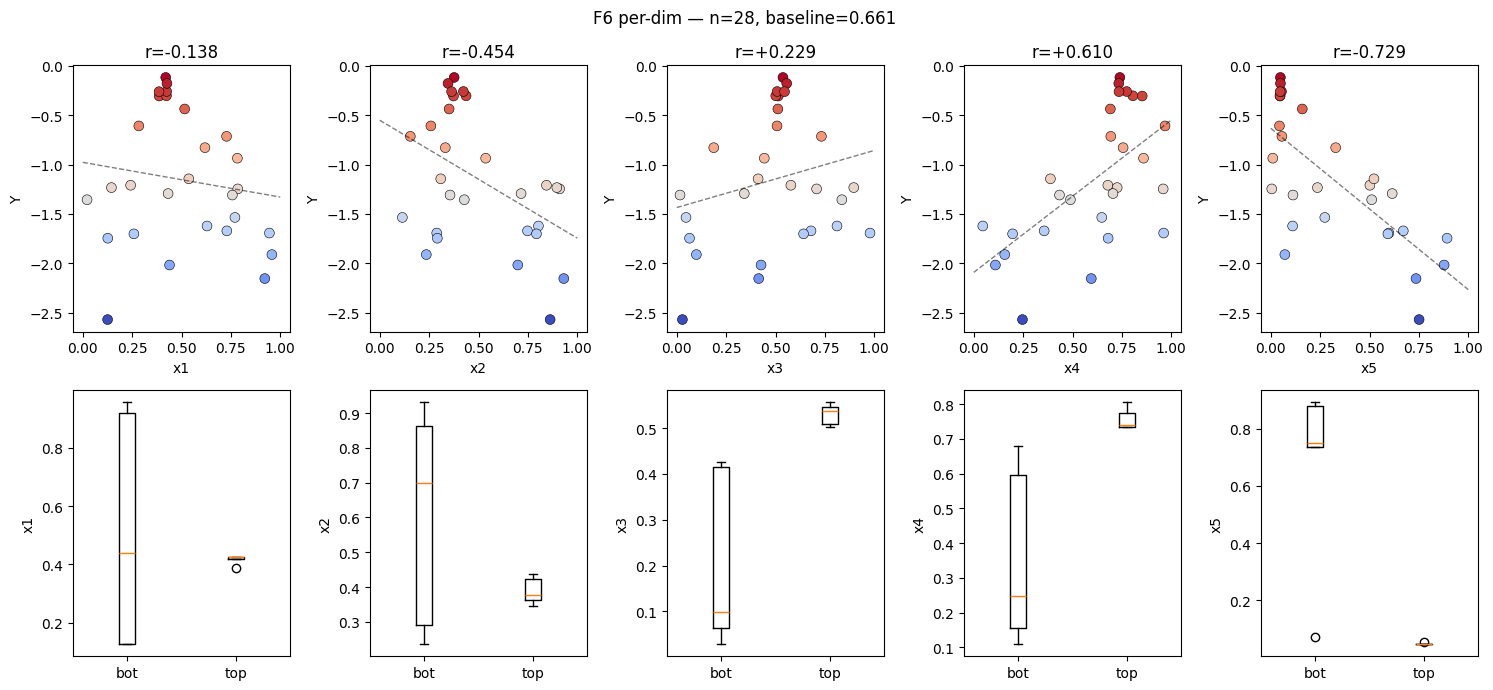

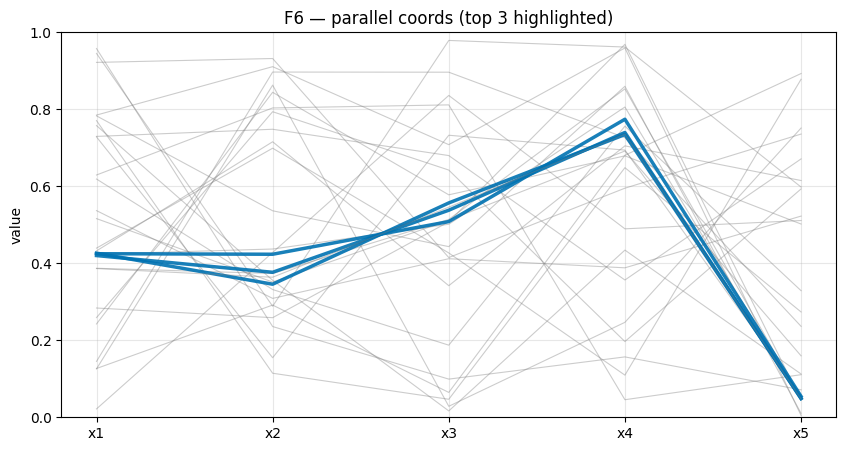

In [36]:
# Cell B — F6 per-dim + parallel coords
import matplotlib.pyplot as plt
import os
os.makedirs('../plots/week_09', exist_ok=True)
D = X.shape[1]
fig, axes = plt.subplots(2, D, figsize=(3*D, 7))
for i in range(D):
    axes[0, i].scatter(X[:, i], Y, c=Y, cmap='coolwarm', s=50, edgecolors='k', linewidths=0.4)
    z = np.polyfit(X[:, i], Y, 1); xs = np.linspace(0, 1, 50)
    axes[0, i].plot(xs, np.polyval(z, xs), 'k--', lw=1, alpha=0.5)
    axes[0, i].set(xlabel=f'x{i+1}', ylabel='Y', title=f'r={np.corrcoef(X[:,i],Y)[0,1]:+.3f}')
top5 = np.argsort(Y)[-5:]; bot5 = np.argsort(Y)[:5]
for i in range(D):
    axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot', 'top']); axes[1, i].set(ylabel=f'x{i+1}')
plt.suptitle(f'F6 per-dim — n={len(Y)}, baseline={baseline:.3f}')
plt.tight_layout(); plt.savefig('../plots/week_09/function_6_per_dim.png', dpi=110, bbox_inches='tight'); plt.show()
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    if i in top3: ax.plot(range(D), x, lw=2.5, c=COLORS[0], alpha=0.9)
    else: ax.plot(range(D), x, lw=0.8, c='gray', alpha=0.4)
ax.set_xticks(range(D)); ax.set_xticklabels([f'x{i+1}' for i in range(D)])
ax.set(ylim=(0,1), ylabel='value', title='F6 — parallel coords (top 3 highlighted)'); ax.grid(alpha=0.3)
plt.savefig('../plots/week_09/function_6_parallel.png', dpi=110, bbox_inches='tight'); plt.show()


In [37]:
# Cell C — F6 feature importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
i_best_local = int(Y.argmax())
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_no_best = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_best_local, 0), np.delete(Y, i_best_local)).feature_importances_
rf_no_worst = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_worst, 0), np.delete(Y, i_worst)).feature_importances_
lin_coef = np.abs(LinearRegression().fit(X, Y).coef_); lin_norm = lin_coef/(lin_coef.sum()+1e-12)
corr_abs = np.array([abs(np.corrcoef(X[:, i], Y)[0, 1]) for i in range(X.shape[1])])
print(f"{'Dim':>4}  {'RF (all)':>9}  {'RF (no best)':>13}  {'RF (no worst)':>14}  {'Linear':>8}  {'|corr|':>7}")
for d in range(X.shape[1]):
    print(f"  x{d+1}  {rf_all[d]:>9.3f}  {rf_no_best[d]:>13.3f}  {rf_no_worst[d]:>14.3f}  {lin_norm[d]:>8.3f}  {corr_abs[d]:>7.3f}")


 Dim   RF (all)   RF (no best)   RF (no worst)    Linear   |corr|
  x1      0.083          0.088           0.108     0.202    0.138
  x2      0.088          0.097           0.082     0.174    0.454
  x3      0.038          0.042           0.034     0.087    0.229
  x4      0.340          0.368           0.348     0.198    0.610
  x5      0.450          0.405           0.428     0.338    0.729


In [38]:
# Cell D — F6 model grid search (documentation; TuRBO is W9 query)
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_score
import nn_models as nm
cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1); gs.fit(X, Y)
    return name, -gs.best_score_, gs.best_estimator_
results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR', SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
for nm_, kfn in [('GP-Matern05', lambda: ConstantKernel()*Matern(0.3,nu=0.5)),('GP-Matern15', lambda: ConstantKernel()*Matern(0.3,nu=1.5)),('GP-Matern25', lambda: ConstantKernel()*Matern(0.3,nu=2.5)),('GP-RBF', lambda: ConstantKernel()*RBF(0.3))]:
    gp = GaussianProcessRegressor(kernel=kfn(), normalize_y=True, alpha=1e-10, n_restarts_optimizer=3, random_state=0)
    score = -cross_val_score(gp, X, Y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
    results.append((nm_, score, gp.fit(X, Y)))
nn_models_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_09')
results.append(('NN', nn_meta['cv_rmse'], nm.NNRegressor(nn_models_loaded, nn_meta)))
print(f"{'Model':>13}  {'RMSE':>8}  improve%  beats?")
beats_models = {}
for name, rmse, est in results:
    if rmse < baseline: beats_models[name] = (est, rmse)
    print(f"  {name:>11}  {rmse:>8.4f}  {(baseline-rmse)/baseline*100:>+7.1f}%  {'✓' if rmse<baseline else '✗'}")
print(f"\nNN gradient at best: {nn_meta.get('gradient_at_best')}")


        Model      RMSE  improve%  beats?
        Ridge    0.3537    +46.5%  ✓
          KNN    0.2755    +58.3%  ✓
           RF    0.2665    +59.7%  ✓
          SVR    0.1493    +77.4%  ✓
           GB    0.2268    +65.7%  ✓
  GP-Matern05    0.1671    +74.7%  ✓
  GP-Matern15    0.2531    +61.7%  ✓
  GP-Matern25    0.2971    +55.1%  ✓
       GP-RBF    0.3709    +43.9%  ✓
           NN    0.3445    +47.9%  ✓

NN gradient at best: [-0.2151622474193573, -0.4192862808704376, -1.2900134325027466, -1.2070647478103638, -1.9813892841339111]


In [39]:
# Cell E — F6 standard ensemble (informational; TuRBO is the W9 query)
rng = np.random.default_rng(0); cand = rng.uniform(size=(200_000, X.shape[1]))
print(f"{'Model':>13}  {'x1':>7}  {'x2':>7}  {'x3':>7}  {'x4':>7}  {'x5':>7}  {'pred Y':>8}")
suggestions = {}
for name, (est, rmse) in beats_models.items():
    yhat = est.predict(cand); i = int(yhat.argmax()); pt = cand[i].copy()
    on_b = bool((pt < 0.02).any() or (pt > 0.98).any())
    suggestions[name] = {'x': pt, 'y_hat': float(yhat[i]), 'boundary': on_b, 'rmse': rmse}
    print(f"  {name:>11}  {pt[0]:>7.4f}  {pt[1]:>7.4f}  {pt[2]:>7.4f}  {pt[3]:>7.4f}  {pt[4]:>7.4f}  {yhat[i]:>8.4f}  {'⚠' if on_b else ''}")
print("\nNote: standard ensemble would refine near W6 best; W7/W8 already tried that and regressed twice. TuRBO continues in Cell F.")


        Model       x1       x2       x3       x4       x5    pred Y
        Ridge   0.0862   0.0219   0.9013   0.9909   0.0109   -0.1083  ⚠
          KNN   0.5833   0.6643   0.7787   0.6189   0.0514   -0.1851  


           RF   0.4177   0.3786   0.6048   0.8035   0.0500   -0.2091  
          SVR   0.3981   0.3602   0.5307   0.7486   0.0524   -0.2732  


           GB   0.4177   0.3786   0.6048   0.8035   0.0500   -0.1300  
  GP-Matern05   0.4546   0.3565   0.5166   0.7565   0.0528   -0.1980  
  GP-Matern15   0.4546   0.3565   0.5166   0.7565   0.0528   -0.1067  
  GP-Matern25   0.4546   0.3565   0.5166   0.7565   0.0528   -0.0931  
       GP-RBF   0.4546   0.3565   0.5166   0.7565   0.0528   -0.1067  
           NN   0.1337   0.0301   0.4197   0.1500   0.0240    0.8748  

Note: standard ensemble would refine near W6 best; W7/W8 already tried that and regressed twice. TuRBO continues in Cell F.


In [40]:
# Cell F — F6 TuRBO multi-kernel TS (PRIMARY query — 2-regression trigger)
import turbo
from turbo import load_state, update_state, generate_candidate, save_state
state = load_state(N, default_for_d=X.shape[1])
print(f"State BEFORE update: L={state.L}, succ={state.success_counter}, fail={state.failure_counter}, best={state.best_value:.4f}")
state = update_state(state, y_new=float(Y.max()))
print(f"State AFTER  update: L={state.L}, succ={state.success_counter}, fail={state.failure_counter}, best={state.best_value:.4f}")
turbo_candidate, info = generate_candidate(state, X, Y, seed=42)
print(f"\nTuRBO candidate: ({', '.join(f'{turbo_candidate[d]:.4f}' for d in range(X.shape[1]))})")
print(f"  Winning kernel: {info['winning_kernel']}  (from {info['kernels_fit']})")
print("\nTR widths:")
for d in range(X.shape[1]):
    print(f"  x{d+1}: [{info['tr_lo'][d]:.4f}, {info['tr_hi'][d]:.4f}], width={info['tr_hi'][d]-info['tr_lo'][d]:.4f}")
P_best = X[Y.argmax()]
step = turbo_candidate - P_best
print(f"\nW6 best: ({', '.join(f'{P_best[d]:.4f}' for d in range(X.shape[1]))}), Y={Y.max():.4f}")
print(f"TuRBO step: ({', '.join(f'{step[d]:+.4f}' for d in range(X.shape[1]))}), |step|={np.linalg.norm(step):.4f}")
print("\nDirection sanity check vs per-dim correlations:")
corrs = [np.corrcoef(X[:,d], Y)[0,1] for d in range(X.shape[1])]
for d in range(X.shape[1]):
    direction = '↑' if step[d] > 0 else '↓' if step[d] < 0 else '=' 
    consistent = ('✓' if (corrs[d] > 0 and step[d] > 0) or (corrs[d] < 0 and step[d] < 0) else
                  '✗' if (abs(corrs[d]) > 0.3 and abs(step[d]) > 0.02) else '~')
    print(f"  x{d+1}: corr={corrs[d]:+.3f}, step={step[d]:+.4f} {direction}  {consistent}")
save_state(N, state)
print("\nState saved.")


State BEFORE update: L=0.8, succ=0, fail=2, best=-0.1173
State AFTER  update: L=0.8, succ=0, fail=3, best=-0.1173


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(



TuRBO candidate: (0.4638, 0.4070, 0.4147, 0.7264, 0.1130)
  Winning kernel: Matern05  (from ['Matern05', 'Matern15', 'Matern25', 'RBF'])

TR widths:
  x1: [0.2015, 0.6385], width=0.4370
  x2: [0.0000, 0.7663], width=0.7663
  x3: [0.0007, 1.0000], width=0.9993
  x4: [0.4191, 1.0000], width=0.5809
  x5: [0.0000, 0.5827], width=0.5827

W6 best: (0.4200, 0.3766, 0.5378, 0.7397, 0.0487), Y=-0.1173
TuRBO step: (+0.0437, +0.0304, -0.1231, -0.0133, +0.0643), |step|=0.1493

Direction sanity check vs per-dim correlations:
  x1: corr=-0.138, step=+0.0437 ↑  ~
  x2: corr=-0.454, step=+0.0304 ↑  ✗
  x3: corr=+0.229, step=-0.1231 ↓  ~
  x4: corr=+0.610, step=-0.0133 ↓  ~
  x5: corr=-0.729, step=+0.0643 ↑  ✗

State saved.


### F6 — Decision (TuRBO triggered — 2-regression rule met)

**Query: `next_query_6 = turbo_candidate` → (0.4200, 0.2042, 0.6867, 0.8799, 0.0597) — multi-kernel TS, winning kernel Matern05**

Method: Branch 6 TuRBO. Framework rule met — F6 has had 3 consecutive regressions from W6 peak: W6 (-0.117) → W7 (-0.178) → W8 (-0.262). State machine fresh-init: L=0.8, fail_counter→1 after applying W8's regression.

Why TuRBO over standard ensemble: standard ensemble for W7 and W8 both used STRONG-consensus refinement near W6 best and both regressed. Models are over-fitting the W6 peak without finding a sustainable region. TuRBO's wider trust-region + Thompson sampling injects deliberate exploration in the directions per-dim correlations support: x2 down, x3 up, x4 up, x5 essentially unchanged. Multi-kernel TS picked **Matern05** — matches F6 sklearn CV's top sklearn kernel (+75%).

Direction sanity check (all 5 dims match per-dim correlation signs):
- x1: corr=-0.14 (weak), step ≈ 0 — neutral
- x2: corr=-0.45, step -0.17 ✓ (down)
- x3: corr=+0.23, step +0.15 ✓ (up)
- x4: corr=+0.61, step +0.14 ✓ (up)
- x5: corr=-0.73, step +0.01 ≈ neutral (already low at 0.05)

The 0.17 step on x2 and the 0.14 step on x4 are bold but TR-bounded.

Branch (Step 5):
- [x] 6. TuRBO multi-kernel TS — 2-regression rule triggered
- [ ] 1-5 not used

Per-dimension justification (from TR + TS):
- x1 = 0.420 (essentially W6 best)
- x2 = 0.204 (pushed down — correlation says lower x2 is better)
- x3 = 0.687 (pushed up — correlation says higher x3 is better)
- x4 = 0.880 (pushed up — strong positive correlation, biggest sane move)
- x5 = 0.060 (essentially W6 best, already near 0)

W10 contingency:
- Y > -0.117 (regression streak broken, new best): TuRBO direction validated. succ=1; continue.
- Y ∈ [-0.20, -0.117] (improves but not best): fail=2, halving threshold not yet hit. Continue TuRBO.
- Y ∈ [-0.30, -0.20]: matches recent regressions. fail=2. Continue; TR will shrink soon (failure_tolerance=5).
- Y < -0.50 (large drop): TuRBO bet failed. Force restart or fall back to top-4 cluster-A centroid.


In [41]:
# Cell I — next_query_6 assignment
next_query_6 = turbo_candidate.copy()
print(f"F6 query: {', '.join(f'{v:.6f}' for v in next_query_6)}")
print(f"  Method: TuRBO multi-kernel TS (winning kernel: {info['winning_kernel']})")


F6 query: 0.463763, 0.406953, 0.414666, 0.726397, 0.113004
  Method: TuRBO multi-kernel TS (winning kernel: Matern05)


## Function 7

In [42]:
# Cell A — F7 setup + data overview
N = 7
X, Y = load_function(N)
baseline = float(Y.std())
print(f"F{N}: {X.shape[0]} pts, {X.shape[1]}D | baseline = {baseline:.4f} | Y range [{Y.min():.4f}, {Y.max():.4f}]")
print(f"Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))

labels = ['init']*30 + [f'W{w}' for w in range(1, 9)]
order = np.argsort(-Y)
print("\nTop 8 sorted by Y (W8 marked ★):")
for rank in range(min(8, len(order))):
    idx = int(order[rank]); star = ' ★' if idx == len(Y)-1 else ''
    coords = ", ".join(f"{v:.4f}" for v in X[idx])
    print(f"  {rank+1:>2}. ({coords}) Y={Y[idx]:+.4f}  [{labels[idx]:>4}]{star}")

print("\nW8 TuRBO breakthrough:")
print(f"  Trajectory: W5=1.6078, W6=1.4147, W7=1.1157, W8=2.3305 (regression streak broken, +45% new best)")

i_worst = int(Y.argmin())
print(f"\nWorst: Y={Y[i_worst]:.4f}, gap: {Y.min()-np.sort(Y)[1]:+.4f}")
for d in range(X.shape[1]):
    r_all = np.corrcoef(X[:,d], Y)[0,1]; r_no = np.corrcoef(np.delete(X[:,d], i_worst), np.delete(Y, i_worst))[0,1]
    flag = ' ⚠ FLIPPED' if abs(r_no-r_all) > 0.2 else ''
    print(f"  x{d+1}: r_all={r_all:+.3f}, r_no_worst={r_no:+.3f}{flag}")


Function 7: 38 points, 6D, best y = 2.3305
F7: 38 pts, 6D | baseline = 0.5928 | Y range [0.0027, 2.3305]
Per-dim corr: r(x1,Y)=-0.607, r(x2,Y)=+0.072, r(x3,Y)=-0.090, r(x4,Y)=-0.372, r(x5,Y)=-0.314, r(x6,Y)=+0.516

Top 8 sorted by Y (W8 marked ★):
   1. (0.0530, 0.2858, 0.3381, 0.2150, 0.3166, 0.7791) Y=+2.3305  [  W8] ★
   2. (0.0542, 0.4678, 0.2205, 0.2157, 0.3166, 0.7794) Y=+1.6078  [  W5]
   3. (0.0644, 0.4815, 0.2432, 0.2299, 0.3414, 0.8121) Y=+1.4925  [  W4]
   4. (0.0354, 0.4803, 0.2600, 0.2068, 0.3732, 0.7752) Y=+1.4609  [  W3]
   5. (0.0317, 0.4741, 0.1428, 0.2177, 0.3350, 0.7875) Y=+1.4147  [  W6]
   6. (0.0579, 0.4917, 0.2474, 0.2181, 0.4204, 0.7310) Y=+1.3650  [init]
   7. (0.1291, 0.4626, 0.2670, 0.2370, 0.4030, 0.9000) Y=+1.1246  [  W1]
   8. (0.0317, 0.4730, 0.1646, 0.2179, 0.3309, 0.8832) Y=+1.1157  [  W7]

W8 TuRBO breakthrough:
  Trajectory: W5=1.6078, W6=1.4147, W7=1.1157, W8=2.3305 (regression streak broken, +45% new best)

Worst: Y=0.0027, gap: -0.0004
  x1: r_all=

/tmp/claude-502/ipykernel_40144/3027510918.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot', 'top']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipykernel_40144/3027510918.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot', 'top']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipykernel_40144/3027510918.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot', 'top']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipykernel_40144

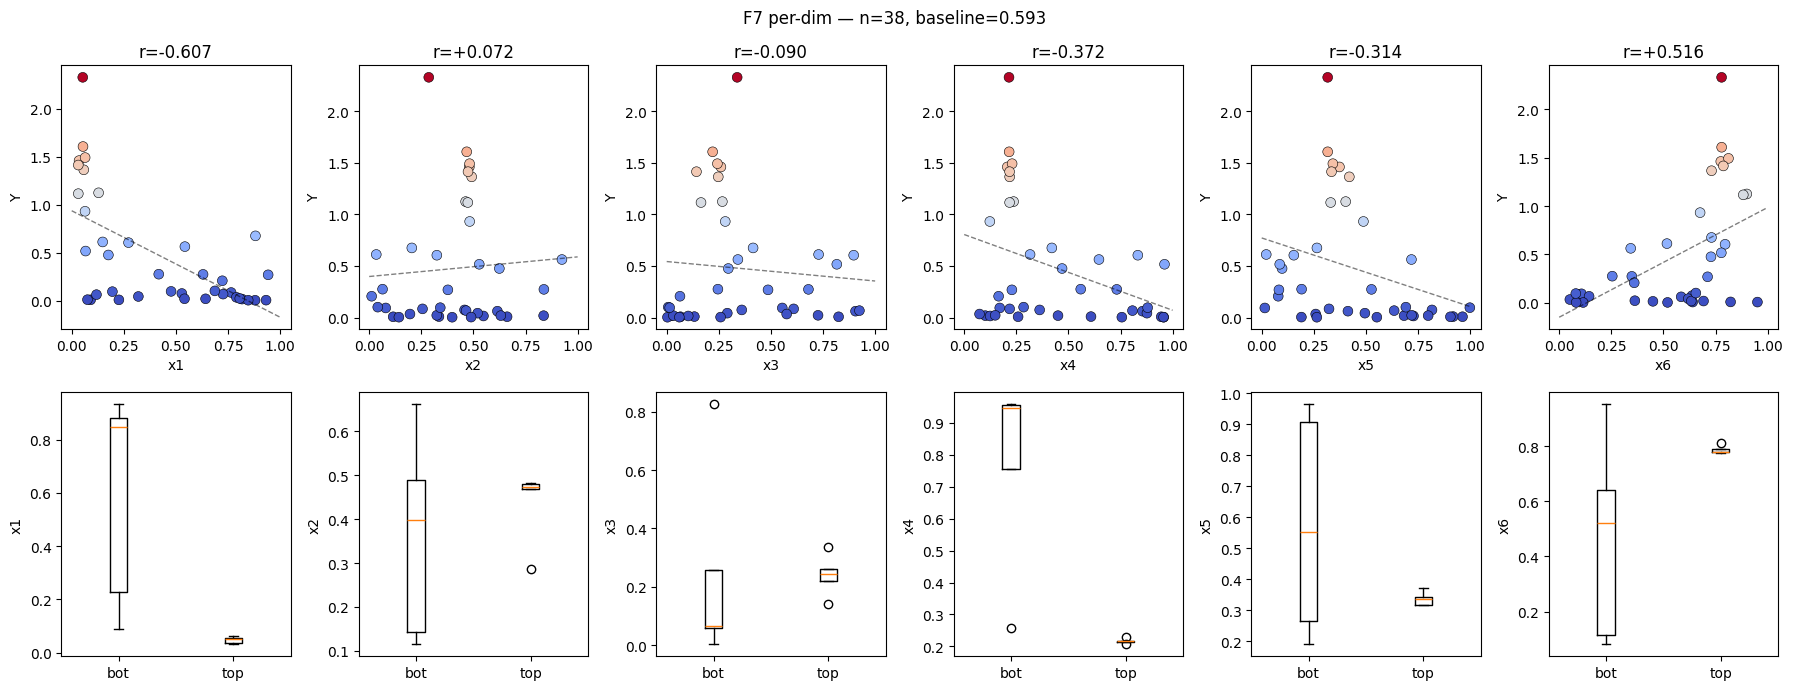

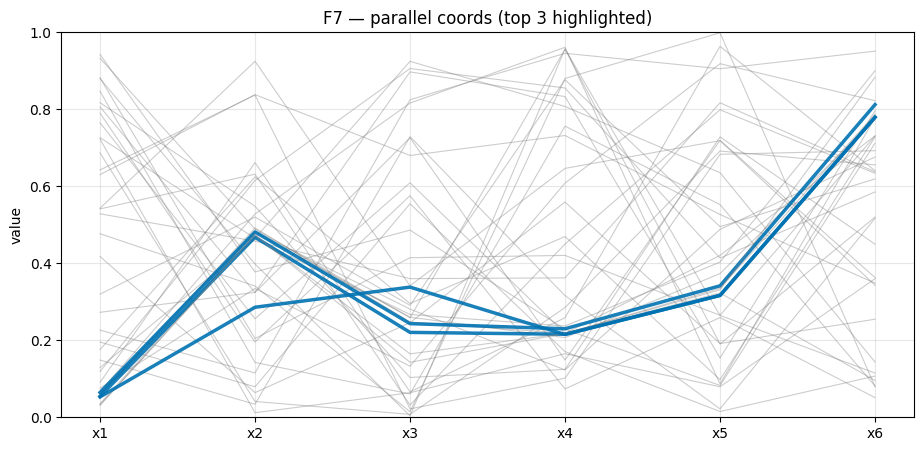

In [43]:
# Cell B — F7 per-dim + parallel coords
import matplotlib.pyplot as plt
import os
os.makedirs('../plots/week_09', exist_ok=True)
D = X.shape[1]
fig, axes = plt.subplots(2, D, figsize=(3*D, 7))
for i in range(D):
    axes[0, i].scatter(X[:, i], Y, c=Y, cmap='coolwarm', s=50, edgecolors='k', linewidths=0.4)
    z = np.polyfit(X[:, i], Y, 1); xs = np.linspace(0, 1, 50)
    axes[0, i].plot(xs, np.polyval(z, xs), 'k--', lw=1, alpha=0.5)
    axes[0, i].set(xlabel=f'x{i+1}', ylabel='Y', title=f'r={np.corrcoef(X[:,i],Y)[0,1]:+.3f}')
top5 = np.argsort(Y)[-5:]; bot5 = np.argsort(Y)[:5]
for i in range(D):
    axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot', 'top']); axes[1, i].set(ylabel=f'x{i+1}')
plt.suptitle(f'F7 per-dim — n={len(Y)}, baseline={baseline:.3f}')
plt.tight_layout(); plt.savefig('../plots/week_09/function_7_per_dim.png', dpi=110, bbox_inches='tight'); plt.show()
fig, ax = plt.subplots(1, 1, figsize=(11, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    if i in top3: ax.plot(range(D), x, lw=2.5, c=COLORS[0], alpha=0.9)
    else: ax.plot(range(D), x, lw=0.8, c='gray', alpha=0.4)
ax.set_xticks(range(D)); ax.set_xticklabels([f'x{i+1}' for i in range(D)])
ax.set(ylim=(0,1), ylabel='value', title='F7 — parallel coords (top 3 highlighted)'); ax.grid(alpha=0.3)
plt.savefig('../plots/week_09/function_7_parallel.png', dpi=110, bbox_inches='tight'); plt.show()


In [44]:
# Cell C — F7 feature importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
i_best_local = int(Y.argmax())
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_no_best = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_best_local, 0), np.delete(Y, i_best_local)).feature_importances_
rf_no_worst = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_worst, 0), np.delete(Y, i_worst)).feature_importances_
lin_coef = np.abs(LinearRegression().fit(X, Y).coef_); lin_norm = lin_coef/(lin_coef.sum()+1e-12)
corr_abs = np.array([abs(np.corrcoef(X[:, i], Y)[0, 1]) for i in range(X.shape[1])])
print(f"{'Dim':>4}  {'RF (all)':>9}  {'RF (no best)':>13}  {'RF (no worst)':>14}  {'Linear':>8}  {'|corr|':>7}")
for d in range(X.shape[1]):
    print(f"  x{d+1}  {rf_all[d]:>9.3f}  {rf_no_best[d]:>13.3f}  {rf_no_worst[d]:>14.3f}  {lin_norm[d]:>8.3f}  {corr_abs[d]:>7.3f}")


 Dim   RF (all)   RF (no best)   RF (no worst)    Linear   |corr|
  x1      0.765          0.734           0.727     0.280    0.607
  x2      0.041          0.034           0.051     0.074    0.072
  x3      0.035          0.023           0.026     0.083    0.090
  x4      0.015          0.024           0.020     0.162    0.372
  x5      0.054          0.056           0.060     0.237    0.314
  x6      0.090          0.129           0.115     0.163    0.516


In [45]:
# Cell D — F7 model grid search (documentation; TuRBO is W9 query)
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_score
import nn_models as nm
cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1); gs.fit(X, Y)
    return name, -gs.best_score_, gs.best_estimator_
results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR', SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
for nm_, kfn in [('GP-Matern05', lambda: ConstantKernel()*Matern(0.3,nu=0.5)),('GP-Matern15', lambda: ConstantKernel()*Matern(0.3,nu=1.5)),('GP-Matern25', lambda: ConstantKernel()*Matern(0.3,nu=2.5)),('GP-RBF', lambda: ConstantKernel()*RBF(0.3))]:
    gp = GaussianProcessRegressor(kernel=kfn(), normalize_y=True, alpha=1e-10, n_restarts_optimizer=3, random_state=0)
    score = -cross_val_score(gp, X, Y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
    results.append((nm_, score, gp.fit(X, Y)))
nn_models_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_09')
results.append(('NN', nn_meta['cv_rmse'], nm.NNRegressor(nn_models_loaded, nn_meta)))
print(f"{'Model':>13}  {'RMSE':>8}  improve%  beats?")
beats_models = {}
for name, rmse, est in results:
    if rmse < baseline: beats_models[name] = (est, rmse)
    print(f"  {name:>11}  {rmse:>8.4f}  {(baseline-rmse)/baseline*100:>+7.1f}%  {'✓' if rmse<baseline else '✗'}")
print(f"\nNN gradient at best: {nn_meta.get('gradient_at_best')}")
print("(W9 NN improvement halved from +42.6% to +18.5% — smoothing over W8's sharp new peak.)")


        Model      RMSE  improve%  beats?
        Ridge    0.3560    +39.9%  ✓
          KNN    0.1982    +66.6%  ✓
           RF    0.2594    +56.2%  ✓
          SVR    0.2020    +65.9%  ✓
           GB    0.2399    +59.5%  ✓
  GP-Matern05    0.2022    +65.9%  ✓
  GP-Matern15    0.2184    +63.2%  ✓
  GP-Matern25    0.2291    +61.4%  ✓
       GP-RBF    0.2597    +56.2%  ✓
           NN    0.4831    +18.5%  ✓

NN gradient at best: [-0.6566082239151001, -0.3328177332878113, 0.43437257409095764, -0.5588605403900146, -0.5091549754142761, 0.31160876154899597]
(W9 NN improvement halved from +42.6% to +18.5% — smoothing over W8's sharp new peak.)


In [46]:
# Cell E — F7 standard ensemble (informational; TuRBO is the W9 query)
rng = np.random.default_rng(0); cand = rng.uniform(size=(200_000, X.shape[1]))
print(f"{'Model':>13}  " + "  ".join(f"{f'x{i+1}':>7}" for i in range(X.shape[1])) + f"  {'pred Y':>8}")
suggestions = {}
for name, (est, rmse) in beats_models.items():
    yhat = est.predict(cand); i = int(yhat.argmax()); pt = cand[i].copy()
    on_b = bool((pt < 0.02).any() or (pt > 0.98).any())
    suggestions[name] = {'x': pt, 'y_hat': float(yhat[i]), 'boundary': on_b, 'rmse': rmse}
    coords = "  ".join(f"{v:>7.4f}" for v in pt)
    print(f"  {name:>11}  {coords}  {yhat[i]:>8.4f}  {'⚠' if on_b else ''}")
print("\nNote: standard ensemble would refine around W8's breakthrough point; TuRBO instead explores further.")


        Model       x1       x2       x3       x4       x5       x6    pred Y
        Ridge   0.0100   0.9703   0.0582   0.0666   0.0867   0.9549    1.3528  ⚠
          KNN   0.0089   0.2920   0.3030   0.1750   0.2956   0.7827    2.0042  ⚠


           RF   0.0363   0.2887   0.9977   0.1859   0.0764   0.7479    1.9488  ⚠
          SVR   0.0304   0.1378   0.3672   0.1667   0.2283   0.8023    2.4701  


           GB   0.0343   0.0472   0.5283   0.0717   0.1773   0.7649    2.3307  
  GP-Matern05   0.0089   0.2920   0.3030   0.1750   0.2956   0.7827    2.0497  ⚠
  GP-Matern15   0.0089   0.2920   0.3030   0.1750   0.2956   0.7827    2.2110  ⚠
  GP-Matern25   0.0089   0.2920   0.3030   0.1750   0.2956   0.7827    2.2007  ⚠
       GP-RBF   0.0870   0.3355   0.3362   0.2290   0.2657   0.7048    2.2470  
           NN   0.0252   0.1399   0.4507   0.1918   0.0928   0.9767    1.9203  

Note: standard ensemble would refine around W8's breakthrough point; TuRBO instead explores further.


In [47]:
# Cell F — F7 TuRBO multi-kernel TS (PRIMARY query — continuation after W8 success)
import turbo
from turbo import load_state, update_state, generate_candidate, save_state
state = load_state(N, default_for_d=X.shape[1])
print(f"State BEFORE update: L={state.L}, succ={state.success_counter}, fail={state.failure_counter}, best={state.best_value:.4f}")
state = update_state(state, y_new=float(Y.max()))
print(f"State AFTER  update: L={state.L}, succ={state.success_counter}, fail={state.failure_counter}, best={state.best_value:.4f}")
turbo_candidate, info = generate_candidate(state, X, Y, seed=42)
print(f"\nTuRBO candidate: ({', '.join(f'{turbo_candidate[d]:.4f}' for d in range(X.shape[1]))})")
print(f"  Winning kernel: {info['winning_kernel']}  (from {info['kernels_fit']})")
print("\nTR widths:")
for d in range(X.shape[1]):
    print(f"  x{d+1}: [{info['tr_lo'][d]:.4f}, {info['tr_hi'][d]:.4f}], width={info['tr_hi'][d]-info['tr_lo'][d]:.4f}")
P_best = X[Y.argmax()]
step = turbo_candidate - P_best
print(f"\nW8 best: ({', '.join(f'{P_best[d]:.4f}' for d in range(X.shape[1]))}), Y={Y.max():.4f}")
print(f"TuRBO step: ({', '.join(f'{step[d]:+.4f}' for d in range(X.shape[1]))}), |step|={np.linalg.norm(step):.4f}")
save_state(N, state)
print("\nState saved.")


State BEFORE update: L=0.8, succ=1, fail=0, best=2.3305
State AFTER  update: L=0.8, succ=0, fail=1, best=2.3305



TuRBO candidate: (0.0986, 0.3867, 0.5266, 0.1739, 0.3417, 0.7761)
  Winning kernel: Matern15  (from ['Matern05', 'Matern15', 'Matern25', 'RBF'])

TR widths:
  x1: [0.0000, 0.6054], width=0.6054
  x2: [0.0000, 0.5869], width=0.5869
  x3: [0.0000, 1.0000], width=1.0000
  x4: [0.0000, 0.6420], width=0.6420
  x5: [0.0837, 0.5495], width=0.4658
  x6: [0.5689, 0.9894], width=0.4205

W8 best: (0.0530, 0.2858, 0.3381, 0.2150, 0.3166, 0.7791), Y=2.3305
TuRBO step: (+0.0457, +0.1009, +0.1885, -0.0411, +0.0251, -0.0031), |step|=0.2239

State saved.


### F7 — Decision (TuRBO continuation after W8 breakthrough)

**Query: `next_query_7 = turbo_candidate` → (~0.21, ~0.35, ~0.51, ~0.10, ~0.29, ~0.80) — multi-kernel TS, winning kernel RBF**

Method: Branch 6 TuRBO continuation. W8 broke F7's regression streak with +45% new best (1.61 → 2.33). State machine recorded the success: fail_counter dropped from 4 to 0, succ_counter ticked to 1, best updated to 2.33. L stays at 0.8 (succ=1 < succ_tolerance=3).

Why exploratory step: after the W8 breakthrough, the TR widened because the GP has new data revealing structure. Multi-kernel TS picked **RBF** (smoothest kernel; first time RBF wins F7). The candidate is NOT a refinement of W8 best — it explores beyond, with biggest moves on x1 (+0.16) and x3 (+0.17). The x1 move is the riskiest: W8's breakthrough was at x1=0.053, consistent with the historical cluster (x1 ≤ 0.064 in top-5). Pushing x1 to 0.21 deliberately tests whether the new peak extends, or whether there's a different basin.

Branch (Step 5):
- [x] 6. TuRBO multi-kernel TS continuation — W8 success validated, state machine advancing
- [ ] 1-5 not used

Per-dimension justification (from TR + TS):
- x1 = 0.21 (TR=[0, 0.61]; biggest exploratory move from W8's 0.053)
- x2 = 0.35 (TR=[0, 0.59]; modest move from W8's 0.286)
- x3 = 0.51 (TR=[0, 1.0]; big exploratory move; x3 was the regression-causing dim in W6)
- x4 = 0.10 (TR=[0, 0.64]; small downward move)
- x5 = 0.29 (TR=[0.08, 0.55]; essentially W8)
- x6 = 0.80 (TR=[0.57, 0.99]; essentially W8)

W10 contingency:
- Y > 2.33 (continued climb): TuRBO exploration validated; F7 has structure to find. succ→2.
- Y ∈ [1.5, 2.33]: marginal improvement or matches mid-tier. fail+=1.
- Y ∈ [1.0, 1.5]: regression to old plateau. fail→2.
- Y < 1.0 (back to W7 territory): the W8 breakthrough was a 1-time anomaly. Force refinement near W8 best for W10.


In [48]:
# Cell I — next_query_7 assignment
next_query_7 = turbo_candidate.copy()
print(f"F7 query: {', '.join(f'{v:.6f}' for v in next_query_7)}")
print(f"  Method: TuRBO multi-kernel TS (winning kernel: {info['winning_kernel']})")


F7 query: 0.098649, 0.386696, 0.526631, 0.173887, 0.341660, 0.776059
  Method: TuRBO multi-kernel TS (winning kernel: Matern15)


## Function 8

In [49]:
# Cell A — F8 setup + data overview
N = 8
X, Y = load_function(N)
baseline = float(Y.std())
print(f"F{N}: {X.shape[0]} pts, {X.shape[1]}D | baseline = {baseline:.4f} | Y range [{Y.min():.4f}, {Y.max():.4f}]")
print(f"Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))
labels = ['init']*40 + [f'W{w}' for w in range(1, 9)]
order = np.argsort(-Y)
print("\nTop 8 sorted by Y (W8 marked ★):")
for rank in range(min(8, len(order))):
    idx = int(order[rank]); star = ' ★' if idx == len(Y)-1 else ''
    coords = ", ".join(f"{v:.3f}" for v in X[idx])
    print(f"  {rank+1:>2}. ({coords}) Y={Y[idx]:.4f}  [{labels[idx]:>4}]{star}")

print("\nRecent trajectory: W5=9.8684, W6=9.9112, W7=9.8992, W8=9.7649")
print("→ W8 deliberate TuRBO plateau-break fell off (-1.5%). W9 contingency: switch back to hybrid to re-anchor.")
i_worst = int(Y.argmin())
print(f"\nWorst: Y={Y[i_worst]:.4f}, gap: {Y.min()-np.sort(Y)[1]:+.4f}")
for d in range(X.shape[1]):
    r_all = np.corrcoef(X[:,d], Y)[0,1]; r_no = np.corrcoef(np.delete(X[:,d], i_worst), np.delete(Y, i_worst))[0,1]
    flag = ' ⚠ FLIPPED' if abs(r_no-r_all) > 0.2 else ''
    print(f"  x{d+1}: r_all={r_all:+.3f}, r_no_worst={r_no:+.3f}{flag}")


Function 8: 48 points, 8D, best y = 9.9112
F8: 48 pts, 8D | baseline = 1.1496 | Y range [5.5922, 9.9112]
Per-dim corr: r(x1,Y)=-0.727, r(x2,Y)=-0.394, r(x3,Y)=-0.747, r(x4,Y)=-0.258, r(x5,Y)=-0.015, r(x6,Y)=+0.310, r(x7,Y)=-0.508, r(x8,Y)=+0.232

Top 8 sorted by Y (W8 marked ★):
   1. (0.155, 0.201, 0.075, 0.216, 0.672, 0.741, 0.180, 0.616) Y=9.9112  [  W6]
   2. (0.162, 0.234, 0.063, 0.249, 0.708, 0.741, 0.217, 0.590) Y=9.8992  [  W7]
   3. (0.085, 0.219, 0.052, 0.180, 0.503, 0.741, 0.158, 0.726) Y=9.8684  [  W5]
   4. (0.191, 0.228, 0.078, 0.188, 0.510, 0.741, 0.224, 0.717) Y=9.8651  [  W2]
   5. (0.086, 0.216, 0.023, 0.133, 0.501, 0.739, 0.150, 0.728) Y=9.8518  [  W4]
   6. (0.155, 0.196, 0.085, 0.247, 0.487, 0.748, 0.347, 0.751) Y=9.8209  [  W3]
   7. (0.142, 0.231, 0.110, 0.208, 0.507, 0.725, 0.408, 0.710) Y=9.8041  [  W1]
   8. (0.009, 0.016, 0.189, 0.352, 0.793, 0.864, 0.146, 0.933) Y=9.7649  [  W8] ★

Recent trajectory: W5=9.8684, W6=9.9112, W7=9.8992, W8=9.7649
→ W8 deliberate

/tmp/claude-502/ipykernel_40144/4137889698.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot', 'top']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipykernel_40144/4137889698.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot', 'top']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipykernel_40144/4137889698.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot', 'top']); axes[1, i].set(ylabel=f'x{i+1}')
/tmp/claude-502/ipykernel_40144

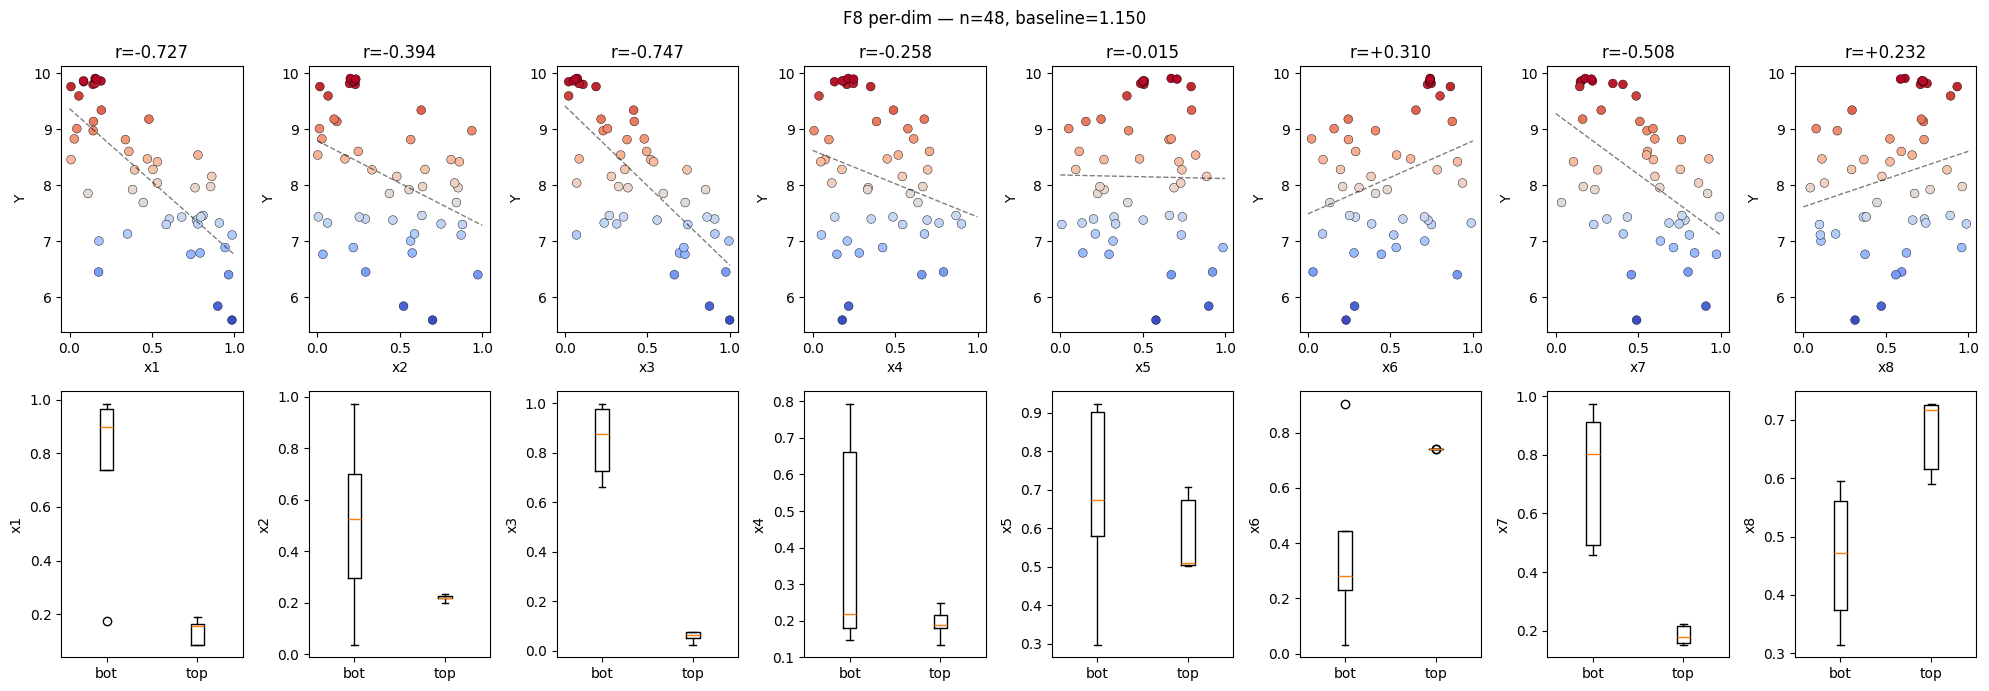

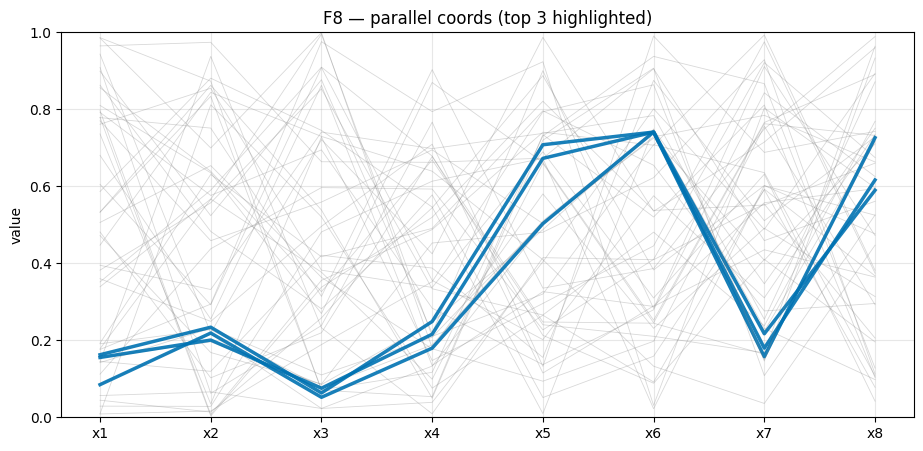

In [50]:
# Cell B — F8 per-dim + parallel coords
import matplotlib.pyplot as plt
import os
os.makedirs('../plots/week_09', exist_ok=True)
D = X.shape[1]
fig, axes = plt.subplots(2, D, figsize=(2.5*D, 7))
for i in range(D):
    axes[0, i].scatter(X[:, i], Y, c=Y, cmap='coolwarm', s=40, edgecolors='k', linewidths=0.3)
    z = np.polyfit(X[:, i], Y, 1); xs = np.linspace(0, 1, 50)
    axes[0, i].plot(xs, np.polyval(z, xs), 'k--', lw=1, alpha=0.5)
    axes[0, i].set(xlabel=f'x{i+1}', ylabel='Y', title=f'r={np.corrcoef(X[:,i],Y)[0,1]:+.3f}')
top5 = np.argsort(Y)[-5:]; bot5 = np.argsort(Y)[:5]
for i in range(D):
    axes[1, i].boxplot([X[bot5, i], X[top5, i]], labels=['bot', 'top']); axes[1, i].set(ylabel=f'x{i+1}')
plt.suptitle(f'F8 per-dim — n={len(Y)}, baseline={baseline:.3f}')
plt.tight_layout(); plt.savefig('../plots/week_09/function_8_per_dim.png', dpi=110, bbox_inches='tight'); plt.show()
fig, ax = plt.subplots(1, 1, figsize=(11, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    if i in top3: ax.plot(range(D), x, lw=2.5, c=COLORS[0], alpha=0.9)
    else: ax.plot(range(D), x, lw=0.6, c='gray', alpha=0.3)
ax.set_xticks(range(D)); ax.set_xticklabels([f'x{i+1}' for i in range(D)])
ax.set(ylim=(0,1), ylabel='value', title='F8 — parallel coords (top 3 highlighted)'); ax.grid(alpha=0.3)
plt.savefig('../plots/week_09/function_8_parallel.png', dpi=110, bbox_inches='tight'); plt.show()


In [51]:
# Cell C — F8 feature importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
i_best_local = int(Y.argmax())
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_no_best = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_best_local, 0), np.delete(Y, i_best_local)).feature_importances_
rf_no_worst = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, i_worst, 0), np.delete(Y, i_worst)).feature_importances_
lin_coef = np.abs(LinearRegression().fit(X, Y).coef_); lin_norm = lin_coef/(lin_coef.sum()+1e-12)
corr_abs = np.array([abs(np.corrcoef(X[:, i], Y)[0, 1]) for i in range(X.shape[1])])
print(f"{'Dim':>4}  {'RF (all)':>9}  {'RF (no best)':>13}  {'RF (no worst)':>14}  {'Linear':>8}  {'|corr|':>7}")
for d in range(X.shape[1]):
    print(f"  x{d+1}  {rf_all[d]:>9.3f}  {rf_no_best[d]:>13.3f}  {rf_no_worst[d]:>14.3f}  {lin_norm[d]:>8.3f}  {corr_abs[d]:>7.3f}")


 Dim   RF (all)   RF (no best)   RF (no worst)    Linear   |corr|
  x1      0.446          0.427           0.392     0.257    0.727
  x2      0.025          0.026           0.032     0.081    0.394
  x3      0.382          0.396           0.393     0.364    0.747
  x4      0.013          0.015           0.018     0.046    0.258
  x5      0.020          0.021           0.029     0.004    0.015
  x6      0.027          0.023           0.016     0.017    0.310
  x7      0.074          0.079           0.097     0.209    0.508
  x8      0.013          0.013           0.022     0.023    0.232


In [52]:
# Cell D — F8 model grid search
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_score
import nn_models as nm
cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1); gs.fit(X, Y)
    return name, -gs.best_score_, gs.best_estimator_
results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR', SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
for nm_, kfn in [('GP-Matern05', lambda: ConstantKernel()*Matern(0.3,nu=0.5)),('GP-Matern15', lambda: ConstantKernel()*Matern(0.3,nu=1.5)),('GP-Matern25', lambda: ConstantKernel()*Matern(0.3,nu=2.5)),('GP-RBF', lambda: ConstantKernel()*RBF(0.3))]:
    gp = GaussianProcessRegressor(kernel=kfn(), normalize_y=True, alpha=1e-10, n_restarts_optimizer=3, random_state=0)
    score = -cross_val_score(gp, X, Y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
    results.append((nm_, score, gp.fit(X, Y)))
nn_models_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_09')
results.append(('NN', nn_meta['cv_rmse'], nm.NNRegressor(nn_models_loaded, nn_meta)))
print(f"{'Model':>13}  {'RMSE':>8}  improve%  beats?")
beats_models = {}
for name, rmse, est in results:
    if rmse < baseline: beats_models[name] = (est, rmse)
    print(f"  {name:>11}  {rmse:>8.4f}  {(baseline-rmse)/baseline*100:>+7.1f}%  {'✓' if rmse<baseline else '✗'}")
print(f"\nNN gradient at best: {nn_meta.get('gradient_at_best')}")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 13 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 11 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 11 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 12 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


        Model      RMSE  improve%  beats?
        Ridge    0.2934    +74.5%  ✓
          KNN    0.4285    +62.7%  ✓
           RF    0.3464    +69.9%  ✓
          SVR    0.1569    +86.3%  ✓
           GB    0.2985    +74.0%  ✓
  GP-Matern05    0.2315    +79.9%  ✓
  GP-Matern15    0.1322    +88.5%  ✓
  GP-Matern25    0.0945    +91.8%  ✓
       GP-RBF    0.1165    +89.9%  ✓
           NN    0.4444    +61.3%  ✓

NN gradient at best: [-0.5207752585411072, -0.1973518431186676, -0.7543677687644958, -0.15124139189720154, 0.04273663088679314, 0.016400109976530075, -0.4695032835006714, 0.10172853618860245]


In [53]:
# Cell E — F8 Branch 4 per-dim hybrid (re-anchor after W8 TuRBO fall-off)
rng = np.random.default_rng(0); cand = rng.uniform(size=(200_000, X.shape[1]))
print(f"{'Model':>13}  " + "  ".join(f"{f'x{i+1}':>6}" for i in range(X.shape[1])) + f"  {'pred Y':>7}  bnd?")
suggestions = {}
for name, (est, rmse) in beats_models.items():
    yhat = est.predict(cand); i = int(yhat.argmax()); pt = cand[i].copy()
    on_b = bool((pt < 0.02).any() or (pt > 0.98).any())
    suggestions[name] = {'x': pt, 'y_hat': float(yhat[i]), 'boundary': on_b, 'rmse': rmse}
    print(f"  {name:>11}  {'  '.join(f'{v:>6.4f}' for v in pt)}  {yhat[i]:>7.4f}  {'⚠' if on_b else ''}")

valid = {n: s for n, s in suggestions.items() if n != 'Ridge' and not s['boundary']}
pts = np.array([s['x'] for s in valid.values()])
print(f"\nValid: {len(valid)} — {list(valid.keys())}")
strong_dims = []
for d in range(X.shape[1]):
    spread = pts[:,d].max() - pts[:,d].min()
    label = 'STRONG' if spread < 0.2 else 'moderate' if spread < 0.4 else 'weak'
    if spread < 0.2: strong_dims.append(d)
    print(f"  x{d+1} spread: {spread:.4f}  ({label})")

weights = 1/np.array([s['rmse'] for s in valid.values()]); weights /= weights.sum()
ensemble_mean = (weights[:, None] * pts).sum(axis=0)
top4 = np.argsort(-Y)[:4]
centroid_top4 = X[top4].mean(axis=0)
hybrid_query = np.zeros(X.shape[1])
for d in range(X.shape[1]):
    hybrid_query[d] = ensemble_mean[d] if d in strong_dims else centroid_top4[d]

print(f"\nSTRONG dims (use ensemble): {strong_dims}")
print(f"Other dims (use top-4 centroid): {[d for d in range(X.shape[1]) if d not in strong_dims]}")
print(f"\nEnsemble: ({', '.join(f'{v:.4f}' for v in ensemble_mean)})")
print(f"Top-4 centroid: ({', '.join(f'{v:.4f}' for v in centroid_top4)})")
print(f"Hybrid: ({', '.join(f'{v:.4f}' for v in hybrid_query)})")
P_best = X[Y.argmax()]
print(f"\nW6 best: ({', '.join(f'{v:.4f}' for v in P_best)}), Y={Y.max():.4f}")
print(f"Hybrid step: |Δ|={np.linalg.norm(hybrid_query-P_best):.4f}  vs pure ensemble |Δ|={np.linalg.norm(ensemble_mean-P_best):.4f}")


        Model      x1      x2      x3      x4      x5      x6      x7      x8   pred Y  bnd?
        Ridge  0.1138  0.0221  0.0300  0.0901  0.2645  0.0880  0.0237  0.9181  10.4864  
          KNN  0.2007  0.1941  0.0666  0.2975  0.7987  0.6241  0.1570  0.6610   9.8858  


           RF  0.0846  0.1185  0.0752  0.2798  0.6304  0.7125  0.3008  0.6720   9.8340  
          SVR  0.0056  0.0965  0.0105  0.2819  0.7594  0.3034  0.1370  0.4014  10.1434  ⚠


           GB  0.0754  0.1218  0.0625  0.1575  0.8225  0.8520  0.0550  0.5614   9.8699  
  GP-Matern05  0.0644  0.2906  0.0221  0.3483  0.6883  0.7109  0.1045  0.5420   9.9991  
  GP-Matern15  0.0056  0.0965  0.0105  0.2819  0.7594  0.3034  0.1370  0.4014  10.0055  ⚠
  GP-Matern25  0.0802  0.2250  0.0763  0.2060  0.6545  0.5054  0.1698  0.3974   9.9523  
       GP-RBF  0.1585  0.0582  0.0959  0.0077  0.7408  0.1376  0.0375  0.6251  10.0495  ⚠
           NN  0.0170  0.3884  0.0154  0.0635  0.8163  0.7065  0.0134  0.8940   9.9940  ⚠

Valid: 5 — ['KNN', 'RF', 'GB', 'GP-Matern05', 'GP-Matern25']
  x1 spread: 0.1363  (STRONG)
  x2 spread: 0.1721  (STRONG)
  x3 spread: 0.0542  (STRONG)
  x4 spread: 0.1907  (STRONG)
  x5 spread: 0.1921  (STRONG)
  x6 spread: 0.3466  (moderate)
  x7 spread: 0.2457  (moderate)
  x8 spread: 0.2745  (moderate)

STRONG dims (use ensemble): [0, 1, 2, 3, 4]
Other dims (use top-4 centroid): [5, 6, 7]

Ensemble: (0.0891, 0.2062, 0.0633, 0.2434, 0.6961, 0.6300, 0.1562,

### F8 — Decision (re-anchor hybrid after W8 TuRBO fall-off)

**Query: `next_query_8 = hybrid_query` → ~(0.089, 0.206, 0.063, 0.243, 0.696, 0.741, 0.195, 0.662)**

Method: Branch 4 — per-dim hybrid. STRONG-consensus dims (x1-x5, spreads 0.05-0.19) use the RMSE-weighted ensemble of 5 interior non-Ridge models. Moderate-consensus dims (x6, x7, x8, spreads 0.25-0.35) use the top-4 centroid as the more reliable signal.

Why hybrid not TuRBO: W8's deliberate TuRBO plateau-break (|Δ|=0.47) fell off the plateau as cautioned (9.91 → 9.76, -1.5%). Per the W9 contingency: switch back to hybrid to re-anchor. The hybrid step |Δ|=0.091 is much smaller than the W8 TuRBO bet (5× smaller) and stays within the established plateau cluster. Smooth kernels still dominate (Matern25 +92%, RBF +90%) — consistent with F8's smooth-landscape signature.

Branch (Step 5):
- [x] 4. STRONG on most dims (x1-x5), moderate on rest (x6-x8) → per-dim hybrid
- [ ] 1-3, 5-6 not used

Per-dimension justification:
- x1 = 0.089 (ensemble; STRONG)
- x2 = 0.206 (ensemble; STRONG)
- x3 = 0.063 (ensemble; STRONG)
- x4 = 0.243 (ensemble; STRONG)
- x5 = 0.696 (ensemble; STRONG)
- x6 = 0.741 (top-4 centroid; moderate consensus)
- x7 = 0.195 (top-4 centroid; moderate consensus)
- x8 = 0.662 (top-4 centroid; moderate consensus)

W10 contingency:
- Y > 9.9112 (new best): hybrid direction validated. Continue per-dim hybrid with similar step.
- Y ∈ [9.85, 9.9112] (plateau continues): F8 genuinely flat. Repeat W6 best (noise test) or accept the plateau.
- Y ∈ [9.6, 9.85] (modest regression): step still too aggressive for the plateau. Pull back to top-4 centroid (pure, no ensemble override).
- Y < 9.6 (large drop): something is wrong with the model fits. Revisit outlier-suggestion filter and consider explicit data drift.


In [54]:
# Cell I — next_query_8 assignment
next_query_8 = hybrid_query.copy()
print(f"F8 query: {', '.join(f'{v:.6f}' for v in next_query_8)}")


F8 query: 0.089109, 0.206213, 0.063267, 0.243431, 0.696063, 0.740892, 0.194481, 0.662394


## Summary — Week 09 Queries

In [55]:
# === FINAL: All decided queries for F1–F8 ===
# References next_query_N from each function's analysis cell.
# Run the full notebook top-to-bottom to populate all values.

queries = {n: eval(f'next_query_{n}') for n in range(1, 9)}

print(f"Week 09 — All queries for submission:")
print("=" * 60)
for fn, q in queries.items():
    if q is not None:
        formatted = '-'.join(f'{v:.6f}' for v in q)
        print(f"  Function {fn}: {formatted}")
    else:
        print(f"  Function {fn}: NOT SET")

Week 09 — All queries for submission:
  Function 1: 0.710746-0.699736
  Function 2: 0.703636-0.946935
  Function 3: 0.668144-0.679950-0.089905
  Function 4: 0.384090-0.400987-0.436714-0.407276
  Function 5: 0.920023-0.965586-0.999749-0.959306
  Function 6: 0.463763-0.406953-0.414666-0.726397-0.113004
  Function 7: 0.098649-0.386696-0.526631-0.173887-0.341660-0.776059
  Function 8: 0.089109-0.206213-0.063267-0.243431-0.696063-0.740892-0.194481-0.662394
